# M11.4 — Analytical versus empirical detector PSD

## Objective

The M10 synthetic domain uses stationary Gaussian noise generated from fixed analytical detector PSDs:

$$
G0 =
\text{Gaussian noise}
+
\text{analytical PSD}.
$$

Real detector data differ from this idealization in several ways. Before introducing actual off-source strain, M11.4 isolates one component of the synthetic-to-real gap: the detector power spectral density.

We define a second synthetic domain:

$$
G1 =
\text{Gaussian noise}
+
\text{empirical PSD estimated from real off-source detector strain}.
$$

Both domains remain Gaussian.

Therefore M11.4 does **not** yet test non-Gaussianity, glitches or non-stationarity of the real strain itself.

The controlled question is:

> How much of the domain shift can be produced solely by replacing the fixed analytical noise spectrum with a real detector noise spectrum?

The experiment is divided into three stages:

1. empirical PSD acquisition and characterization;
2. controlled G0 versus G1 signal/noise comparison;
3. frozen-M10 representation and prediction comparison.

## 1. Hypotheses

### H1 — PSD mismatch

The analytical M10 PSDs and empirical detector PSDs should differ in frequency-dependent structure.

In particular, empirical PSDs may contain:

- detector-specific sensitivity differences;
- narrow spectral lines;
- broad-band deviations from the design curve;
- run- and time-dependent sensitivity structure.

### H2 — Gaussian noise with empirical PSD

Even if the stochastic noise remains Gaussian, replacing

$$
S_n^{G0}(f)
$$

with

$$
S_n^{G1}(f)
$$

changes the distribution of raw strain.

Therefore

$$
n_{G0}(t)
\not\sim
n_{G1}(t)
$$

in their spectral content, even though both are Gaussian processes.

### H3 — Whitening may reduce but not necessarily eliminate the difference

If each domain is whitened using the same PSD from which its noise was generated, the ideal Gaussian components should become substantially more similar after preprocessing.

However, differences can remain because:

- whitening is finite-length;
- PSD estimation is finite-resolution;
- empirical PSDs contain sharper spectral structure;
- the signal is weighted differently across frequency before whitening/filtering.

### H4 — frozen M10 sensitivity

If M10 has learned features that depend on the analytical training-noise spectrum, G1 may shift its embedding or predictions even after the existing M10 preprocessing and per-detector z-score normalization.

In [1]:
EVENT_NAME = "GW170814"
EVENT_TIME = 1186741861.5

PSD_WINDOW = (-1024.0, -640.0)
PSD_SEGMENT_DURATION = 8.0

DETECTORS = ["H1", "L1", "V1"]

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance

from pycbc.types import TimeSeries, FrequencySeries

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.real_data.psd import (
    estimate_offsource_psd,
    psd_window_is_available_and_finite,
)

from src.real_data.gwosc_utils import (
    read_gwosc_hdf5_as_pycbc_timeseries,
)

from src.config import SimulationConfig
from src.dataset import DatasetBuilder
from src.parameters import CBCParameters
from src.snr import compute_network_optimal_snr

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

## 2. Frozen processing configuration

M11.4 keeps the M10 preprocessing contract fixed.

Only the PSD/noise domain is changed.

The output therefore remains:

- 4096 Hz sampling;
- 4 s final CNN window;
- processing context;
- PSD whitening;
- 30 Hz high-pass;
- 512 Hz low-pass;
- no internal strain standardization;
- M10 per-sample/per-detector z-score before CNN inference.

In [3]:
config = SimulationConfig(
    sampling_frequency=4096.0,
    duration=4.0,
    low_frequency_cutoff=30.0,
    waveform_approximant="SEOBNRv4_opt",

    # Para esta primera prueba prefiero NO reescalar distancia
    target_network_snr_range=None,

    processing_context_start_samples=1664,
    processing_context_end_samples=1664,
)

In [4]:
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=DETECTORS,
    signal_processor_kwargs={
        "whitening_method": "psd",
        "apply_highpass": True,
        "apply_lowpass": True,
        "apply_standardization": False,
        "output_mode": "crop_to_config",
        "whitening_low_frequency_cutoff": 30.0,
        "whitening_max_filter_duration": 0.5,
        "whitening_trunc_method": "hann",
        "highpass_frequency": 30.0,
        "lowpass_frequency": 512.0,
        "fir_order": 256,
        "fir_beta": 5.0,
        "remove_corrupted": True,
    },
    rng=np.random.default_rng(123),
)

In [76]:
injector = builder.signal_injector
processor = builder.signal_processor
noise_model = builder.noise_model

print(type(injector).__name__)
print(type(processor).__name__)
print(type(noise_model).__name__)

SignalInjector
SignalProcessor
NoiseModel


### Event selection

GW170814 is retained as the initial M11.4 PSD benchmark because it was already used extensively during M10 real-event validation.

The event belongs to an earlier GWOSC catalog than `GWTC-3-confident`; therefore the corresponding catalog is loaded explicitly rather than mixing event identifiers across catalogs.

At this stage the event is used only as a convenient source of validated off-source detector strain from which to estimate empirical PSDs. The GW signal itself is not used in the G1 synthetic domain.

In [5]:
from src.real_data.catalog import (fetch_gwosc_catalog_events, 
                                   gwosc_events_to_parameter_df,
                                   build_gwosc_urls_for_events)

from src.real_data.gwosc_utils import (download_if_needed)

In [6]:
GWOSC_CATALOG = "GWTC-1-confident"

gwosc_events = fetch_gwosc_catalog_events(
    catalog=GWOSC_CATALOG,
    include_default_parameters=True,
)

gwosc_catalog_df = gwosc_events_to_parameter_df(
    gwosc_events,
    catalog_name=GWOSC_CATALOG,
)

GWOSC_URLS_ACTIVE, gwosc_url_failures_df = (
    build_gwosc_urls_for_events(
        gwosc_catalog_df,
        catalog=GWOSC_CATALOG,
        sample_rate=4096,
    )
)

print("Number of active events:", len(GWOSC_URLS_ACTIVE))
print("GW170814 available:", "GW170814" in GWOSC_URLS_ACTIVE)

Number of active events: 11
GW170814 available: True


In [7]:
EVENT_NAME = "GW170814"

if EVENT_NAME not in GWOSC_URLS_ACTIVE:
    raise KeyError(
        f"{EVENT_NAME} not found in catalog {GWOSC_CATALOG}. "
        f"Available examples: {list(GWOSC_URLS_ACTIVE)[:10]}"
    )

GWOSC_CACHE_DIR = Path("gwosc_cache")
GWOSC_CACHE_DIR.mkdir(exist_ok=True)

In [8]:
# We filter those events without a complete H1-L1-V1 set

event_urls = GWOSC_URLS_ACTIVE[EVENT_NAME]

missing = [
    det
    for det in DETECTORS
    if det not in event_urls
]

if missing:
    raise ValueError(
        f"{EVENT_NAME} does not provide all required detectors. "
        f"Missing: {missing}. "
        f"Available: {list(event_urls)}"
    )

In [9]:
raw_strains_long = {}

for det in DETECTORS:

    url = event_urls[det]

    local_path = download_if_needed(
        url,
        cache_dir=GWOSC_CACHE_DIR,
    )

    raw_strains_long[det] = (
        read_gwosc_hdf5_as_pycbc_timeseries(
            local_path
        )
    )

Using cached file: H-H1_GWOSC_4KHZ_R1-1186739814-4096.hdf5
Using cached file: L-L1_GWOSC_4KHZ_R1-1186739814-4096.hdf5
Using cached file: V-V1_GWOSC_4KHZ_R1-1186739814-4096.hdf5


In [10]:
for ifo, strain in raw_strains_long.items():

    print(
        ifo,
        len(strain),
        float(strain.start_time),
        float(strain.end_time),
        float(strain.delta_t),
    )

H1 16777216 1186739814.0 1186743910.0 0.000244140625
L1 16777216 1186739814.0 1186743910.0 0.000244140625
V1 16777216 1186739814.0 1186743910.0 0.000244140625


### Getting the emphirical PSD

We need to resolutions:

- 4s PSD for optimal-SNR analysis, 
- PSD for ``processing_length`` (whitening).

In [11]:
empirical_psds_processing = {}

for ifo in DETECTORS:

    empirical_psds_processing[ifo] = (
        estimate_offsource_psd(
            strain=raw_strains_long[ifo],
            event_time=EVENT_TIME,
            delta_f=config.processing_delta_f,
            sampling_frequency=config.sampling_frequency,
            target_flength=config.processing_flength,
            psd_start_offset=PSD_WINDOW[0],
            psd_end_offset=PSD_WINDOW[1],
            psd_segment_duration=PSD_SEGMENT_DURATION,
            low_frequency_cutoff=config.low_frequency_cutoff,
            max_filter_duration=0.5,
            trunc_method="hann",
        )
    )

In [12]:
empirical_psds_4s = {}

for ifo in DETECTORS:

    empirical_psds_4s[ifo] = (
        estimate_offsource_psd(
            strain=raw_strains_long[ifo],
            event_time=EVENT_TIME,
            delta_f=config.delta_f,
            sampling_frequency=config.sampling_frequency,
            target_flength=config.flength,
            psd_start_offset=PSD_WINDOW[0],
            psd_end_offset=PSD_WINDOW[1],
            psd_segment_duration=PSD_SEGMENT_DURATION,
            low_frequency_cutoff=config.low_frequency_cutoff,
            max_filter_duration=0.5,
            trunc_method="hann",
        )
    )

In [13]:
analytical_psds_processing = {
    ifo: builder.noise_model.get_psd(
        ifo,
        length=config.processing_length,
    )
    for ifo in DETECTORS
}

analytical_psds_4s = {
    ifo: builder.noise_model.get_psd(
        ifo,
        length=config.length,
    )
    for ifo in DETECTORS
}

In [14]:
def summarize_psd_contract(psds):

    rows = []

    for ifo, psd in psds.items():

        arr = psd.numpy()

        rows.append({
            "ifo": ifo,
            "length": len(psd),
            "delta_f": float(psd.delta_f),
            "finite": bool(
                np.all(np.isfinite(arr))
            ),
            "nonnegative": bool(
                np.all(arr >= 0)
            ),
            "n_zero": int(
                np.sum(arr == 0)
            ),
        })

    return pd.DataFrame(rows)

In [15]:
print("Analytical:")
display(
    summarize_psd_contract(
        analytical_psds_processing
    )
)

print("Empirical:")
display(
    summarize_psd_contract(
        empirical_psds_processing
    )
)

Analytical:


,ifo,length,delta_f,finite,nonnegative,n_zero
0,H1,9857,0.207792,True,True,145
1,L1,9857,0.207792,True,True,145
2,V1,9857,0.207792,True,True,145


Empirical:


,ifo,length,delta_f,finite,nonnegative,n_zero
0,H1,9857,0.207792,True,True,0
1,L1,9857,0.207792,True,True,0
2,V1,9857,0.207792,True,True,0


## 3. Analytical versus empirical detector sensitivity

The PSD itself spans many orders of magnitude.

For visualization we therefore use the amplitude spectral density,

$$
\mathrm{ASD}(f)
=
\sqrt{S_n(f)}.
$$

The objective is not only to compare overall scale, but also frequency-dependent structure.

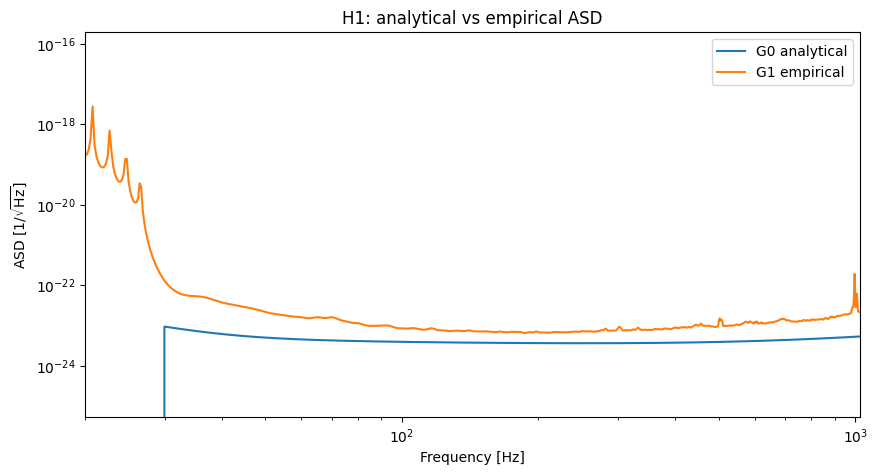

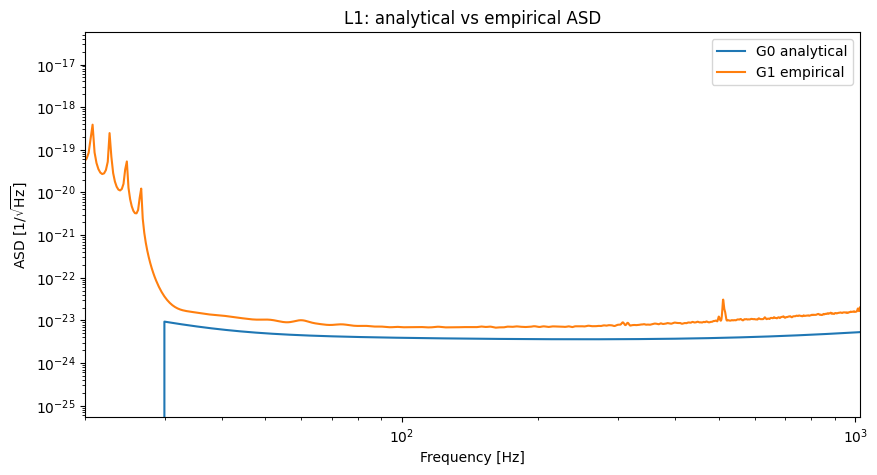

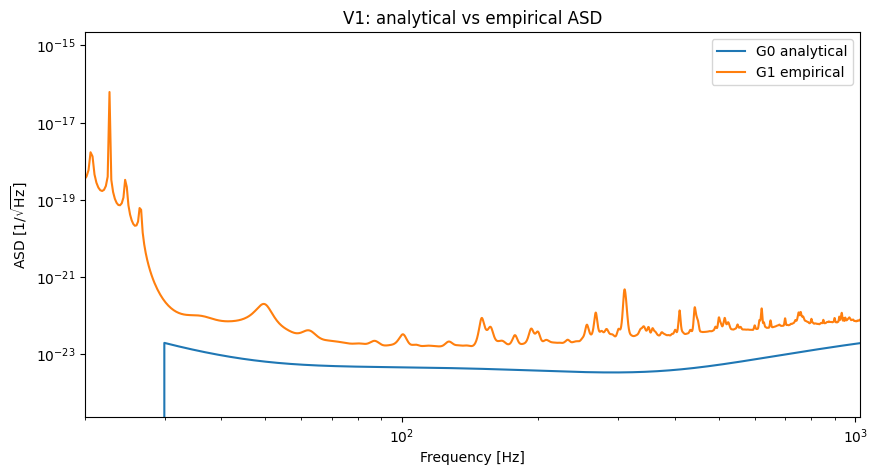

In [16]:
for ifo in DETECTORS:

    p0 = analytical_psds_processing[ifo]
    p1 = empirical_psds_processing[ifo]

    f0 = p0.sample_frequencies.numpy()
    f1 = p1.sample_frequencies.numpy()

    plt.figure(figsize=(10, 5))

    plt.loglog(
        f0,
        np.sqrt(p0.numpy()),
        label="G0 analytical",
    )

    plt.loglog(
        f1,
        np.sqrt(p1.numpy()),
        label="G1 empirical",
    )

    plt.xlim(20, 1024)

    plt.xlabel("Frequency [Hz]")
    plt.ylabel(r"ASD [$1/\sqrt{\mathrm{Hz}}$]")
    plt.title(f"{ifo}: analytical vs empirical ASD")
    plt.legend()

    plt.show()

Also we can visualize the PSD-ratio between these two regimes:

$$
R_I(f) = \frac{S^{G1}_{n, I}(f)}{S^{G0}_{n, I}(f)}
$$

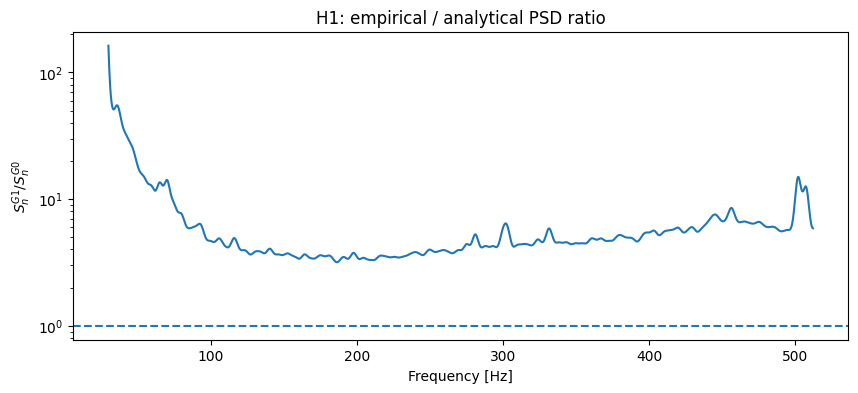

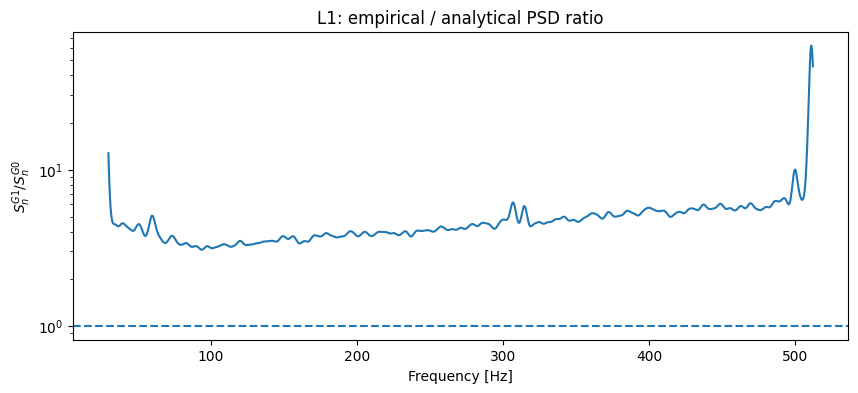

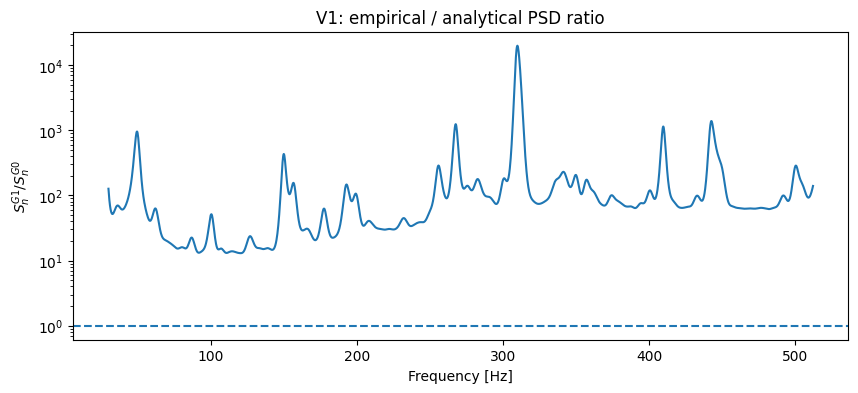

In [17]:
for ifo in DETECTORS:

    p0 = analytical_psds_processing[ifo]
    p1 = empirical_psds_processing[ifo]

    f = p0.sample_frequencies.numpy()

    a0 = p0.numpy()
    a1 = p1.numpy()

    valid = (
        (f >= 30.0)
        & (f <= 512.0)
        & (a0 > 0)
        & (a1 > 0)
        & np.isfinite(a0)
        & np.isfinite(a1)
    )

    ratio = (
        a1[valid]
        / a0[valid]
    )

    plt.figure(figsize=(10, 4))

    plt.semilogy(
        f[valid],
        ratio,
    )

    plt.axhline(
        1.0,
        linestyle="--",
    )

    plt.xlabel("Frequency [Hz]")
    plt.ylabel(
        r"$S_n^{G1}/S_n^{G0}$"
    )

    plt.title(
        f"{ifo}: empirical / analytical PSD ratio"
    )

    plt.show()

Summary for freq-bands

In [18]:
BANDS = [
    (30, 60),
    (60, 120),
    (120, 256),
    (256, 512),
]

In [19]:
rows = []

for ifo in DETECTORS:

    p0 = analytical_psds_processing[ifo]
    p1 = empirical_psds_processing[ifo]

    f = p0.sample_frequencies.numpy()

    a0 = p0.numpy()
    a1 = p1.numpy()

    for fmin, fmax in BANDS:

        mask = (
            (f >= fmin)
            & (f < fmax)
            & (a0 > 0)
            & (a1 > 0)
        )

        log_ratio = np.log10(
            a1[mask] / a0[mask]
        )

        rows.append({
            "ifo": ifo,
            "fmin": fmin,
            "fmax": fmax,
            "median_psd_ratio":
                np.median(
                    a1[mask] / a0[mask]
                ),
            "median_log10_ratio":
                np.median(log_ratio),
            "q10_log10_ratio":
                np.quantile(
                    log_ratio,
                    0.10,
                ),
            "q90_log10_ratio":
                np.quantile(
                    log_ratio,
                    0.90,
                ),
        })

df_psd_band_summary = pd.DataFrame(rows)

df_psd_band_summary

,ifo,fmin,fmax,median_psd_ratio,median_log10_ratio,q10_log10_ratio,q90_log10_ratio
0,H1,30,60,28.020298,1.447467,1.127062,1.738872
1,H1,60,120,5.998227,0.778023,0.642329,1.111110
2,H1,120,256,3.579163,0.553781,0.528022,0.588277
3,H1,256,512,5.195123,0.715596,0.625717,0.842795
4,L1,30,60,4.362630,0.639748,0.598054,0.690904
5,L1,60,120,3.301249,0.518678,0.498348,0.573784
6,L1,120,256,3.765685,0.575844,0.530941,0.604842
7,L1,256,512,5.249780,0.720141,0.637346,0.788670
8,V1,30,60,69.775157,1.843701,1.678225,2.714672
9,V1,60,120,16.023735,1.204764,1.125372,1.639692


# 4. M11.4-B — Signal weighting under G0 and G1

The exact same projected GW signal is evaluated under the analytical and empirical detector PSDs.

No stochastic noise is involved in this comparison.

Therefore any SNR difference is produced exclusively by the detector sensitivity model.

The same physical signal would have different optimal SNR, according to the used PSD

$$
\rho_{\mathrm{opt}}
= \sqrt{
4
\int
\frac{|h(f)|^2}
{S_n(f)}
\,df
}.
$$

It is reasonable to ask ourselves, 

> How much changes the source strenght (detectability) just because the spectral sensibility changes as well?


P1 — misma fuente física
$$ h_{G0}=h_{G1}. $$

Misma distancia y waveform.

Entonces:

$$ \rho_{\rm opt}^{G0} \neq \rho_{\rm opt}^{G1}. $$

Pregunta:

> ¿Cuánto cambia la detectabilidad de exactamente la misma fuente sólo porque cambia la sensibilidad detector?

P2 — misma optimal SNR

Reescalamos la distancia independientemente bajo cada PSD para imponer:

$$ \rho_{\rm opt}^{G0} = \rho_{\rm opt}^{G1}. $$

Pregunta:

> Una vez eliminada la diferencia trivial de detectabilidad global, ¿queda un cambio por la forma espectral de G1?

Las dos son necesarias porque responden preguntas distintas.

In [20]:
params = CBCParameters(
    mass_1=30.0,
    mass_2=30.0,
    distance=500.0,
    inclination=1.0,
    ra=1.0,
    dec=0.3,
    spin_1z=0.0,
    spin_2z=0.0,
    polarization_angle=0.5,
)

T_GEO = EVENT_TIME
PLACEMENT_POLICY = "centered"

In [21]:
network_P1 = builder._build_projected_signal_network(
    params=params,
    geocentric_coalescence_time=T_GEO,
    placement_policy=PLACEMENT_POLICY,
)

In [22]:
print("distance:", network_P1.params.distance)
print("chirp mass:", network_P1.params.chirp_mass)
print("total mass:", network_P1.params.total_mass)
print("chi_eff:", network_P1.params.chi_eff)
print("G0 builder network SNR:", network_P1.network_snr)
print("detector SNRs:", network_P1.detector_snrs)

distance: 500.0
chirp mass: 26.11651689888372
total mass: 60.0
chi_eff: 0.0
G0 builder network SNR: 44.686448483449674
detector SNRs: {'H1': 22.975143916201674, 'L1': 34.33040075191095, 'V1': 17.042447720530497}


In [23]:
det_snr_G0_P1, net_snr_G0_P1 = (
    compute_network_optimal_snr(
        signal_segments=network_P1.signal_segments,
        psds=analytical_psds_4s,
        config=config,
    )
)

det_snr_G1_P1, net_snr_G1_P1 = (
    compute_network_optimal_snr(
        signal_segments=network_P1.signal_segments,
        psds=empirical_psds_4s,
        config=config,
    )
)

In [24]:
rows = []

for ifo in DETECTORS:

    rows.append({
        "ifo": ifo,
        "rho_G0": det_snr_G0_P1[ifo],
        "rho_G1": det_snr_G1_P1[ifo],
        "rho_ratio_G1_G0":
            det_snr_G1_P1[ifo]
            / det_snr_G0_P1[ifo],
        "rho_loss_fraction":
            1.0
            - det_snr_G1_P1[ifo]
            / det_snr_G0_P1[ifo],
    })

df_P1_snr = pd.DataFrame(rows)

df_P1_snr

,ifo,rho_G0,rho_G1,rho_ratio_G1_G0,rho_loss_fraction
0,H1,22.975144,8.457588,0.368119,0.631881
1,L1,34.330401,17.551840,0.511262,0.488738
2,V1,17.042448,3.034859,0.178076,0.821924


In [25]:
print(
    "G0 network optimal SNR:",
    net_snr_G0_P1,
)

print(
    "G1 network optimal SNR:",
    net_snr_G1_P1,
)

print(
    "Network ratio G1/G0:",
    net_snr_G1_P1
    / net_snr_G0_P1,
)

G0 network optimal SNR: 44.686448483449674
G1 network optimal SNR: 19.718221098979456
Network ratio G1/G0: 0.4412572886897111


## Frequency-resolved signal information

The optimal SNR compresses the full frequency-dependent signal weighting into one scalar.

To identify where the empirical PSD changes the available signal information, we inspect

$$
\frac{d\rho^2}{df}
=
4
\frac{|\tilde h(f)|^2}
{S_n(f)}.
$$

This quantity shows which frequency regions contribute most strongly to the matched-filter information under each detector-noise model.

In [26]:
def snr2_density(
    signal,
    psd,
    f_low,
    f_high=None,
):
    hf = signal.to_frequencyseries()

    freqs = hf.sample_frequencies.numpy()
    h = hf.numpy()
    s = psd.numpy()

    valid = (
        (freqs >= f_low)
        & (s > 0)
        & np.isfinite(s)
    )

    if f_high is not None:
        valid &= freqs <= f_high

    density = np.full_like(
        freqs,
        np.nan,
        dtype=np.float64,
    )

    density[valid] = (
        4.0
        * np.abs(h[valid])**2
        / s[valid]
    )

    return freqs, density

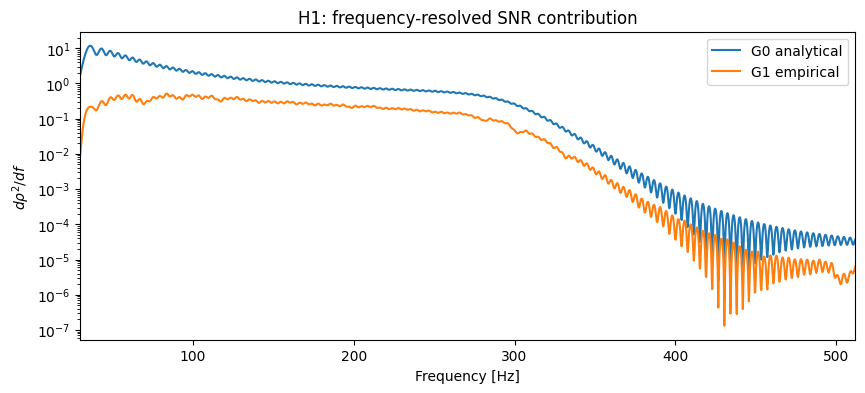

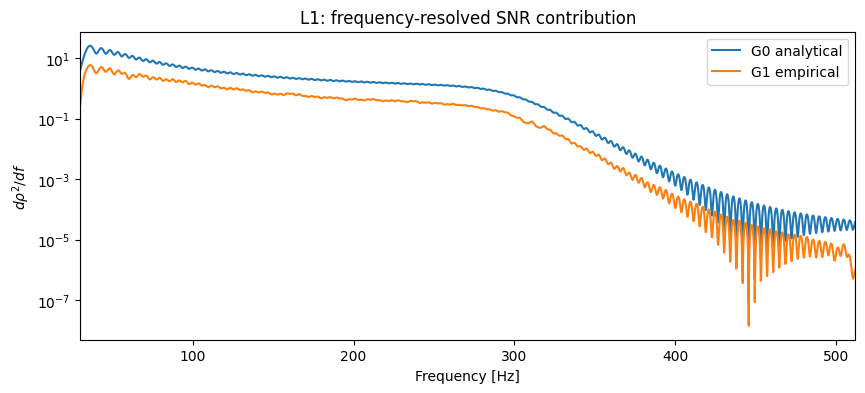

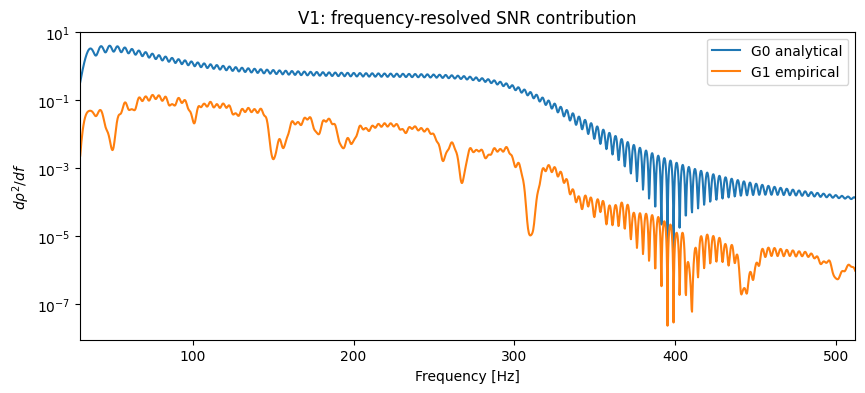

In [27]:
for ifo in DETECTORS:

    f0, d0 = snr2_density(
        network_P1.signal_segments[ifo],
        analytical_psds_4s[ifo],
        config.low_frequency_cutoff,
        512.0,
    )

    f1, d1 = snr2_density(
        network_P1.signal_segments[ifo],
        empirical_psds_4s[ifo],
        config.low_frequency_cutoff,
        512.0,
    )

    valid0 = np.isfinite(d0)
    valid1 = np.isfinite(d1)

    plt.figure(figsize=(10, 4))

    plt.semilogy(
        f0[valid0],
        d0[valid0],
        label="G0 analytical",
    )

    plt.semilogy(
        f1[valid1],
        d1[valid1],
        label="G1 empirical",
    )

    plt.xlim(30, 512)

    plt.xlabel("Frequency [Hz]")
    plt.ylabel(
        r"$d\rho^2/df$"
    )

    plt.title(
        f"{ifo}: frequency-resolved SNR contribution"
    )

    plt.legend()
    plt.show()

In [28]:
def snr2_in_band(
    signal,
    psd,
    fmin,
    fmax,
):
    hf = signal.to_frequencyseries()

    f = hf.sample_frequencies.numpy()
    h = hf.numpy()
    s = psd.numpy()

    mask = (
        (f >= fmin)
        & (f < fmax)
        & (s > 0)
        & np.isfinite(s)
    )

    return float(
        4.0
        * float(hf.delta_f)
        * np.sum(
            np.abs(h[mask])**2
            / s[mask]
        )
    )

In [29]:
rows = []

for ifo in DETECTORS:

    for fmin, fmax in BANDS:

        rho2_G0 = snr2_in_band(
            network_P1.signal_segments[ifo],
            analytical_psds_4s[ifo],
            fmin,
            fmax,
        )

        rho2_G1 = snr2_in_band(
            network_P1.signal_segments[ifo],
            empirical_psds_4s[ifo],
            fmin,
            fmax,
        )

        rows.append({
            "ifo": ifo,
            "fmin": fmin,
            "fmax": fmax,
            "rho2_G0": rho2_G0,
            "rho2_G1": rho2_G1,
            "rho2_ratio_G1_G0":
                (
                    rho2_G1 / rho2_G0
                    if rho2_G0 > 0
                    else np.nan
                ),
        })

df_P1_snr_bands = pd.DataFrame(rows)

df_P1_snr_bands

,ifo,fmin,fmax,rho2_G0,rho2_G1,rho2_ratio_G1_G0
0,H1,30,60,215.961564,8.461909,0.039182
1,H1,60,120,166.074919,23.519142,0.141618
2,H1,120,256,121.404315,33.594656,0.276717
3,H1,256,512,24.407439,5.776987,0.236690
4,L1,30,60,482.052572,111.970139,0.232278
5,L1,60,120,370.784837,108.619272,0.292944
6,L1,120,256,271.183622,74.869820,0.276085
7,L1,256,512,54.547274,12.458154,0.228392
8,V1,30,60,85.579807,1.036762,0.012115
9,V1,60,120,97.179967,5.082962,0.052305


Now we inspect the P2 case, where we impose the same $\rho_{\rm opt}$ for the two regimes, i.e, modifying the distance so the signal have the same strenght.

While P1 asked about the same source, P2 is asking for same matched-filter difficulty.

In [30]:
TARGET_P2 = 15.0

distance_G0 = (
    network_P1.params.distance
    * net_snr_G0_P1
    / TARGET_P2
)

distance_G1 = (
    network_P1.params.distance
    * net_snr_G1_P1
    / TARGET_P2
)

print("distance for G0:", distance_G0)
print("distance for G1:", distance_G1)

distance for G0: 1489.5482827816559
distance for G1: 657.2740366326485


In [31]:
params_G0_P2 = (
    params.with_distance(
        distance_G0
    )
)

params_G1_P2 = (
    params.with_distance(
        distance_G1
    )
)

In [32]:
#Different networks because h changes (because of the d re-scaling)

network_G0_P2 = (
    builder._build_projected_signal_network(
        params=params_G0_P2,
        geocentric_coalescence_time=T_GEO,
        placement_policy=PLACEMENT_POLICY,
    )
)

network_G1_P2 = (
    builder._build_projected_signal_network(
        params=params_G1_P2,
        geocentric_coalescence_time=T_GEO,
        placement_policy=PLACEMENT_POLICY,
    )
)

In [33]:
_, rho_G0_P2 = (
    compute_network_optimal_snr(
        signal_segments=network_G0_P2.signal_segments,
        psds=analytical_psds_4s,
        config=config,
    )
)

_, rho_G1_P2 = (
    compute_network_optimal_snr(
        signal_segments=network_G1_P2.signal_segments,
        psds=empirical_psds_4s,
        config=config,
    )
)

print(
    "G0 controlled SNR:",
    rho_G0_P2,
)

print(
    "G1 controlled SNR:",
    rho_G1_P2,
)

G0 controlled SNR: 15.000000000000009
G1 controlled SNR: 15.00000000000001


## M11.4-B intermediate conclusion

M11.4-B confirms that replacing the analytical M10 detector PSDs by empirical off-source PSDs produces a large change in the effective sensitivity to the same physical GW signal.

For the controlled $30+30\,M_\odot$ BBH at 500 Mpc,

$$
\rho_{\rm net,opt}^{G0}
=
44.69,
$$

whereas

$$
\rho_{\rm net,opt}^{G1}
=
19.72.
$$

Therefore,

$$
\frac{
\rho_{\rm net,opt}^{G1}
}{
\rho_{\rm net,opt}^{G0}
}
\simeq
0.44.
$$

The detector-level effect is strongly heterogeneous, with the largest degradation occurring in Virgo.

The frequency-resolved analysis further shows that this is not a simple overall amplitude shift. The empirical PSD changes the relative contribution of different frequency regions to the available matched-filter information.

Thus the transition

$$
G0
\rightarrow
G1
$$

changes both:

1. the total expected detectability of a fixed physical source;
2. the frequency-dependent weighting of the signal.

A second controlled comparison was therefore constructed at fixed network optimal SNR,

$$
\rho_{\rm net,opt}=15.
$$

This requires different luminosity distances,

$$
d_{G0}\simeq1489.55\ {\rm Mpc},
$$

and

$$
d_{G1}\simeq657.27\ {\rm Mpc},
$$

but successfully removes total optimal SNR as a confounding variable.

The next experiment compares Gaussian G0 and G1 observations under this fixed-SNR condition.

In [34]:
from pycbc.noise import gaussian

In [35]:
def sample_noise_from_psd(
    psd,
    length,
    delta_t,
    seed,
):
    return gaussian.noise_from_psd(
        psd=psd,
        length=length,
        delta_t=delta_t,
        seed=seed,
    )

In [36]:
for ifo in DETECTORS:

    assert (
        len(analytical_psds_processing[ifo])
        == config.processing_flength
    )

    assert (
        len(empirical_psds_processing[ifo])
        == config.processing_flength
    )

    assert np.isclose(
        analytical_psds_processing[ifo].delta_f,
        config.processing_delta_f,
    )

    assert np.isclose(
        empirical_psds_processing[ifo].delta_f,
        config.processing_delta_f,
    )

print("Processing PSD contracts passed.")

Processing PSD contracts passed.


In [38]:
TEST_SEED = 30_000

noise_G0_test = {}
noise_G1_test = {}

for k, ifo in enumerate(DETECTORS):

    seed = TEST_SEED + k

    noise_G0_test[ifo] = sample_noise_from_psd(
        psd=analytical_psds_processing[ifo],
        length=config.processing_length,
        delta_t=config.delta_t,
        seed=seed,
    )

    noise_G1_test[ifo] = sample_noise_from_psd(
        psd=empirical_psds_processing[ifo],
        length=config.processing_length,
        delta_t=config.delta_t,
        seed=seed,
    )

In [39]:
def compare_underlying_white_draw(
    n0,
    n1,
    psd0,
    psd1,
    f_low=30.0,
    f_high=512.0,
):
    f0 = n0.to_frequencyseries()
    f1 = n1.to_frequencyseries()

    freq = f0.sample_frequencies.numpy()

    a0 = f0.numpy()
    a1 = f1.numpy()

    p0 = psd0.numpy()
    p1 = psd1.numpy()

    mask = (
        (freq >= f_low)
        & (freq <= f_high)
        & (p0 > 0)
        & (p1 > 0)
        & np.isfinite(p0)
        & np.isfinite(p1)
    )

    w0 = (
        a0[mask]
        / np.sqrt(p0[mask])
    )

    w1 = (
        a1[mask]
        / np.sqrt(p1[mask])
    )

    rel_l2 = (
        np.linalg.norm(w0 - w1)
        / np.linalg.norm(w0)
    )

    complex_corr = (
        np.vdot(w0, w1)
        / (
            np.linalg.norm(w0)
            * np.linalg.norm(w1)
        )
    )

    return {
        "relative_l2": float(rel_l2),
        "abs_complex_correlation":
            float(np.abs(complex_corr)),
        "real_complex_correlation":
            float(np.real(complex_corr)),
    }

In [40]:
rows = []

for ifo in DETECTORS:

    result = compare_underlying_white_draw(
        noise_G0_test[ifo],
        noise_G1_test[ifo],
        analytical_psds_processing[ifo],
        empirical_psds_processing[ifo],
    )

    rows.append({
        "ifo": ifo,
        **result,
    })

df_white_pairing_check = pd.DataFrame(rows)

df_white_pairing_check

,ifo,relative_l2,abs_complex_correlation,real_complex_correlation
0,H1,3405.033266,0.008156,-0.007409
1,L1,109.776577,0.028724,-0.006714
2,V1,22629.680475,0.024831,0.015892


### Pairing check result

Using the same random seed in `pycbc.noise.gaussian.noise_from_psd` does not produce a common underlying whitened realization when the input PSD is changed.

The recovered frequency-domain draws are essentially uncorrelated between G0 and G1:

$$
\mathrm{corr}
\left(
\frac{\tilde n_{G0}}{\sqrt{S_{G0}}},
\frac{\tilde n_{G1}}{\sqrt{S_{G1}}}
\right)
\approx0.
$$

Therefore equal PyCBC seeds cannot be used as evidence of a paired G0/G1 Gaussian-noise realization.

Continuing with this construction would confound the PSD-domain effect with ordinary noise-realization variability.

The noisy G0/G1 comparison is therefore paused until a common-white-draw construction is explicitly implemented and validated.

Las realizaciones no comparten el mismo white draw subyacente (como fondo blanco que se multiplica por el $S_n(f)$ para "colorearlo").

## *Generador Freq-domain común

In [41]:
from pycbc.types import FrequencySeries

In [42]:
def generate_common_white_frequency_draw(
    flength,
    seed,
):
    """
    Generate the dimensionless Gaussian frequency-domain random draw
    used to construct a real time series.

    Interior positive-frequency bins contain independent complex
    standard-normal draws.

    DC and Nyquist bins are real.
    """
    rng = np.random.default_rng(seed)

    real = rng.normal(
        size=flength
    )

    imag = rng.normal(
        size=flength
    )

    z = real + 1j * imag

    # Real-valued time series constraints for rFFT endpoints.
    z[0] = real[0] + 0j
    z[-1] = real[-1] + 0j

    return z

In [43]:
def color_frequency_draw_with_psd(
    z,
    psd,
):
    """
    Color one common dimensionless frequency draw with a
    one-sided PSD.

    Returns a PyCBC FrequencySeries.
    """
    s = np.asarray(
        psd.numpy(),
        dtype=np.float64,
    )

    if len(z) != len(s):
        raise ValueError(
            "White draw and PSD length mismatch."
        )

    df = float(psd.delta_f)

    out = np.zeros(
        len(s),
        dtype=np.complex128,
    )

    valid = (
        np.isfinite(s)
        & (s > 0)
    )

    scale = np.zeros_like(s)

    scale[valid] = np.sqrt(
        s[valid]
        / (4.0 * df)
    )

    out[valid] = (
        z[valid]
        * scale[valid]
    )

    # Endpoint bins must be purely real.
    out[0] = np.real(out[0]) + 0j
    out[-1] = np.real(out[-1]) + 0j

    return FrequencySeries(
        out,
        delta_f=df,
    )

In [48]:
# Pasar a time Series

def paired_noise_from_psds(
    psd0,
    psd1,
    seed,
):
    if len(psd0) != len(psd1):
        raise ValueError(
            "PSD length mismatch."
        )

    if not np.isclose(
        psd0.delta_f,
        psd1.delta_f,
    ):
        raise ValueError(
            "PSD delta_f mismatch."
        )

    z = generate_common_white_frequency_draw(
        flength=len(psd0),
        seed=seed,
    )

    n0_f = color_frequency_draw_with_psd(
        z,
        psd0,
    )

    n1_f = color_frequency_draw_with_psd(
        z,
        psd1,
    )

    n0 = n0_f.to_timeseries()
    n1 = n1_f.to_timeseries()

    return n0, n1


In [47]:
#Validamos primero el pairing

TEST_SEED_COMMON = 31_000

paired_G0 = {}
paired_G1 = {}

for ifo in DETECTORS:

    n0, n1 = paired_noise_from_psds(
        analytical_psds_processing[ifo],
        empirical_psds_processing[ifo],
        seed=TEST_SEED_COMMON,
    )

    paired_G0[ifo] = n0
    paired_G1[ifo] = n1

In [49]:
rows = []

for ifo in DETECTORS:

    result = compare_underlying_white_draw(
        paired_G0[ifo],
        paired_G1[ifo],
        analytical_psds_processing[ifo],
        empirical_psds_processing[ifo],
    )

    rows.append({
        "ifo": ifo,
        **result,
    })

df_explicit_pairing_check = (
    pd.DataFrame(rows)
)

df_explicit_pairing_check

,ifo,relative_l2,abs_complex_correlation,real_complex_correlation
0,H1,4.054735e-11,1.0,1.0
1,L1,1.892723e-11,1.0,1.0
2,V1,1.696880e-10,1.0,1.0


## *Amplitud correcta: normalizando el ruido 

In [51]:
N_VALIDATE = 100
VALIDATE_IFO = "H1"

std_manual = []
std_pycbc = []

for j in range(N_VALIDATE):

    seed = 60_000 + j

    z = generate_common_white_frequency_draw(
        flength=len(
            analytical_psds_processing[
                VALIDATE_IFO
            ]
        ),
        seed=seed,
    )

    nf = color_frequency_draw_with_psd(
        z,
        analytical_psds_processing[
            VALIDATE_IFO
        ],
    )

    nt = nf.to_timeseries()

    npy = sample_noise_from_psd(
        psd=analytical_psds_processing[
            VALIDATE_IFO
        ],
        length=config.processing_length,
        delta_t=config.delta_t,
        seed=seed,
    )

    std_manual.append(
        np.std(nt.numpy())
    )

    std_pycbc.append(
        np.std(npy.numpy())
    )

In [52]:
print(
    "manual mean std:",
    np.mean(std_manual),
)

print(
    "PyCBC mean std:",
    np.mean(std_pycbc),
)

print(
    "ratio manual / PyCBC:",
    np.mean(std_manual)
    / np.mean(std_pycbc),
)

manual mean std: 2.6725145821879524e-22
PyCBC mean std: 2.6749559376046006e-22
ratio manual / PyCBC: 0.999087328736026


## *PSD recovered (OK check)

In [53]:
N_PSD_VALIDATE = 20

manual_psd_estimates = []

for j in range(N_PSD_VALIDATE):

    seed = 70_000 + j

    z = generate_common_white_frequency_draw(
        flength=len(
            analytical_psds_processing["H1"]
        ),
        seed=seed,
    )

    nf = color_frequency_draw_with_psd(
        z,
        analytical_psds_processing["H1"],
    )

    nt = nf.to_timeseries()

    estimated = nt.psd(
        segment_duration=1.0,
    )

    manual_psd_estimates.append(
        estimated
    )

In [55]:
# Average the recovered PSD estimates.
psd_est_mean = np.mean(
    np.stack([
        p.numpy()
        for p in manual_psd_estimates
    ]),
    axis=0,
)

psd_est_ref = manual_psd_estimates[0]

freq_est = (
    psd_est_ref
    .sample_frequencies
    .numpy()
)

target_psd = (
    analytical_psds_processing["H1"]
)

freq_target = (
    target_psd
    .sample_frequencies
    .numpy()
)

target_arr = target_psd.numpy()

# Interpolate target PSD to recovered-PSD frequency grid.
target_interp = np.interp(
    freq_est,
    freq_target,
    target_arr,
)

valid = (
    (freq_est >= 30.0)
    & (freq_est <= 512.0)
    & np.isfinite(psd_est_mean)
    & np.isfinite(target_interp)
    & (psd_est_mean > 0)
    & (target_interp > 0)
)

ratio = (
    psd_est_mean[valid]
    / target_interp[valid]
)

print(
    "Median recovered/target PSD:",
    np.median(ratio),
)

print(
    "q10:",
    np.quantile(ratio, 0.10),
)

print(
    "q90:",
    np.quantile(ratio, 0.90),
)

Median recovered/target PSD: 0.9962488345208613
q10: 0.8715199776768635
q90: 1.1214195211731643


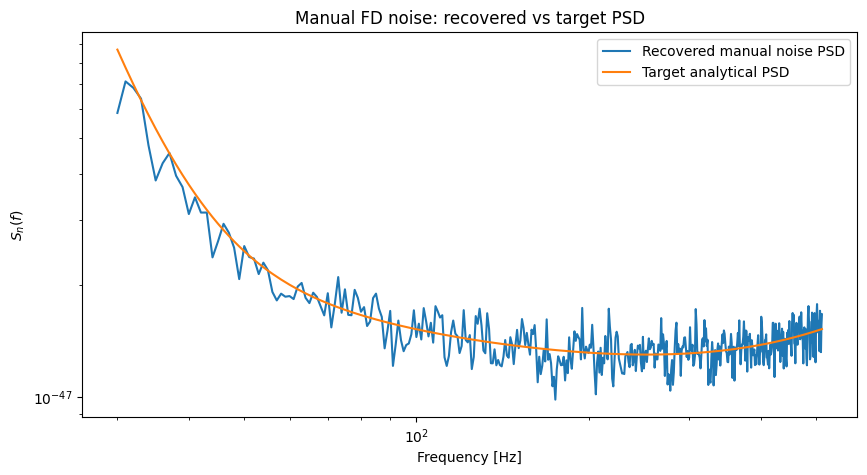

In [56]:
plt.figure(figsize=(10, 5))

plt.loglog(
    freq_est[valid],
    psd_est_mean[valid],
    label="Recovered manual noise PSD",
)

plt.loglog(
    freq_est[valid],
    target_interp[valid],
    label="Target analytical PSD",
)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$S_n(f)$")
plt.title("Manual FD noise: recovered vs target PSD")
plt.legend()

plt.show()

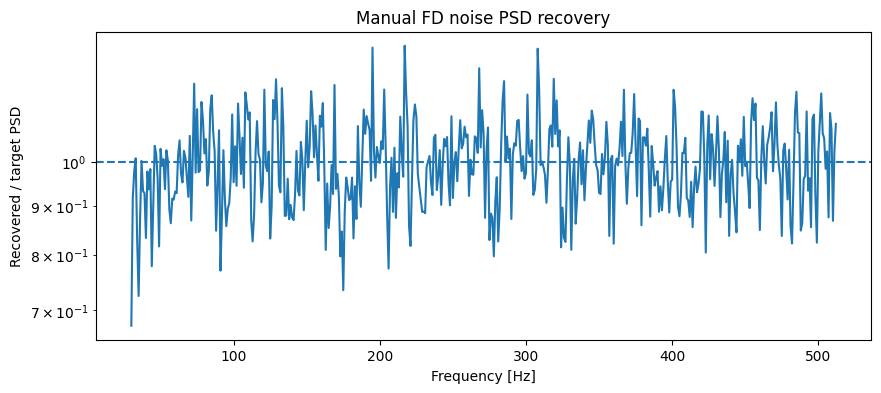

In [57]:
plt.figure(figsize=(10, 4))

plt.semilogy(
    freq_est[valid],
    ratio,
)

plt.axhline(
    1.0,
    linestyle="--",
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Recovered / target PSD")
plt.title(
    "Manual FD noise PSD recovery"
)

plt.show()

## *Recover M11.3 result

In [58]:
psds_G0_4s = analytical_psds_4s

In [64]:
def sample_manual_network_noise_4s(
    psds,
    seed,
):
    noises = {}

    for k, ifo in enumerate(DETECTORS):

        detector_seed = (
            seed
            + 10_000 * k
        )

        z = generate_common_white_frequency_draw(
            flength=len(psds[ifo]),
            seed=detector_seed,
        )

        nf = color_frequency_draw_with_psd(
            z,
            psds[ifo],
        )

        nt = nf.to_timeseries()

        nt.start_time = (
            network_G0_P2
            .signal_segments[ifo]
            .start_time
        )

        noises[ifo] = nt

    return noises


def noise_weighted_inner_product(
    a,
    b,
    psd,
    f_low,
):
    """
    Real noise-weighted inner product

        (a|b) = 4 Re sum a*(f) b(f) / S_n(f) df

    using the positive-frequency representation.
    """
    a_f = a.to_frequencyseries()
    b_f = b.to_frequencyseries()

    if len(a_f) != len(b_f):
        raise ValueError("Frequency-series length mismatch.")

    if len(a_f) != len(psd):
        raise ValueError("PSD length mismatch.")

    if not np.isclose(a_f.delta_f, psd.delta_f):
        raise ValueError("delta_f mismatch.")

    freqs = a_f.sample_frequencies.numpy()

    a_arr = a_f.numpy()
    b_arr = b_f.numpy()
    psd_arr = psd.numpy()

    mask = (
        (freqs >= f_low)
        & np.isfinite(psd_arr)
        & (psd_arr > 0)
    )

    inner = (
        4.0
        * float(a_f.delta_f)
        * np.real(
            np.sum(
                np.conjugate(a_arr[mask])
                * b_arr[mask]
                / psd_arr[mask]
            )
        )
    )

    return float(inner)


# Helper to compute realized SNR

def compute_detector_realized_snr(
    data_segment,
    signal_segment,
    psd,
    f_low,
):
    hh = noise_weighted_inner_product(
        signal_segment,
        signal_segment,
        psd,
        f_low,
    )

    xh = noise_weighted_inner_product(
        data_segment,
        signal_segment,
        psd,
        f_low,
    )

    rho_opt = np.sqrt(hh)
    rho_real = xh / rho_opt

    return {
        "rho_opt": float(rho_opt),
        "rho_real": float(rho_real),
        "noise_projection": float(
            rho_real - rho_opt
        ),
        "hh": float(hh),
        "xh": float(xh),
    }

def compute_network_realized_snr(
    data_segments,
    signal_segments,
    psds,
    f_low,
):
    hh_total = 0.0
    xh_total = 0.0

    detector_results = {}

    for ifo in signal_segments:

        result = compute_detector_realized_snr(
            data_segment=data_segments[ifo],
            signal_segment=signal_segments[ifo],
            psd=psds[ifo],
            f_low=f_low,
        )

        detector_results[ifo] = result

        hh_total += result["hh"]
        xh_total += result["xh"]

    rho_net_opt = np.sqrt(hh_total)

    rho_net_real = (
        xh_total / rho_net_opt
    )

    return (
        detector_results,
        float(rho_net_opt),
        float(rho_net_real),
    )

In [65]:
N_RHO_VALIDATE = 200

delta_rho_manual = []

for j in range(N_RHO_VALIDATE):

    noises = sample_manual_network_noise_4s(
        psds=psds_G0_4s,
        seed=80_000 + j,
    )

    data_segments = {
        ifo:
            noises[ifo]
            + network_G0_P2.signal_segments[ifo]
        for ifo in DETECTORS
    }

    _, rho_opt, rho_real = (
        compute_network_realized_snr(
            data_segments=data_segments,
            signal_segments=(
                network_G0_P2.signal_segments
            ),
            psds=psds_G0_4s,
            f_low=(
                config.low_frequency_cutoff
            ),
        )
    )

    delta_rho_manual.append(
        rho_real - rho_opt
    )

delta_rho_manual = np.asarray(
    delta_rho_manual
)

In [66]:
print(
    "mean delta rho:",
    delta_rho_manual.mean(),
)

print(
    "std delta rho:",
    delta_rho_manual.std(ddof=1),
)

print(
    "q05:",
    np.quantile(
        delta_rho_manual,
        0.05,
    ),
)

print(
    "q95:",
    np.quantile(
        delta_rho_manual,
        0.95,
    ),
)

mean delta rho: 0.023347475442567135
std delta rho: 0.9687413613306355
q05: -1.589353176272562
q95: 1.620829844544409


## Validation of the explicit paired Gaussian generator

The initial attempt to pair G0 and G1 Gaussian noise using identical PyCBC seeds failed: changing the PSD also changed the recovered underlying whitened realization.

An explicit frequency-domain construction was therefore implemented.

For each detector and realization, a common dimensionless Gaussian draw

$$
w_I(f)
$$

is generated once and independently colored using

$$
S_{n,I}^{G0}(f)
$$

and

$$
S_{n,I}^{G1}(f).
$$

The resulting G0/G1 pair satisfies

$$
\frac{
\tilde n_{G0}(f)
}{
\sqrt{S_n^{G0}(f)}
}
\approx
\frac{
\tilde n_{G1}(f)
}{
\sqrt{S_n^{G1}(f)}
},
$$

with frequency-domain correlations numerically equal to unity and relative differences of order

$$
10^{-10}
$$

or smaller.

The overall strain scale also agrees with PyCBC Gaussian-noise generation:

$$
\frac{
\sigma_{\rm manual}
}{
\sigma_{\rm PyCBC}
}
\simeq
0.999.
$$

Therefore the explicit generator provides a valid paired construction in which the underlying Gaussian realization is held fixed while only the detector PSD is changed.

This construction will be used for the controlled G0/G1 comparison.

# M11.4-C — Paired Gaussian G0 versus G1 at fixed optimal SNR

M11.4-A established that the empirical detector PSDs differ strongly from the analytical M10 PSDs in both overall sensitivity and frequency-dependent structure.

M11.4-B showed that the same physical GW therefore has very different optimal SNR under the two domains.

To isolate PSD shape from total signal strength, two versions of the same physical BBH source were constructed such that

$$
\rho_{\rm net,opt}^{G0}
=
\rho_{\rm net,opt}^{G1}
=
15.
$$

The luminosity distances are different, but all intrinsic source parameters, detector geometry and temporal placement are identical.

M11.4-C now compares the two Gaussian domains using a paired-noise construction.

For realization $j$ and detector $I$, the same underlying dimensionless Gaussian draw

$$
w_{I,j}(f)
$$

is colored with either

$$
S_{n,I}^{G0}(f)
$$

or

$$
S_{n,I}^{G1}(f).
$$

Therefore the comparison holds fixed:

- the underlying Gaussian random realization;
- source intrinsic parameters;
- detector geometry;
- placement;
- network optimal SNR;
- preprocessing;
- M10 normalization;
- frozen CNN.

The controlled variable is the detector PSD.

The objective is to determine whether the PSD change remains visible after whitening and M10 input normalization, and whether it propagates into the learned representation and physical predictions.

## M11.4-C helper objects and frozen M10 preprocessing contract

The paired G0/G1 experiment reuses the existing DatasetBuilder components and the exact M10 input-normalization convention.

In [67]:
N_C = 30
C_SEED0 = 100_000

print("N paired realizations:", N_C)
print("G0 optimal SNR:", rho_G0_P2)
print("G1 optimal SNR:", rho_G1_P2)
print(
    "G0 distance [Mpc]:",
    network_G0_P2.params.distance,
)
print(
    "G1 distance [Mpc]:",
    network_G1_P2.params.distance,
)

N paired realizations: 30
G0 optimal SNR: 15.000000000000009
G1 optimal SNR: 15.00000000000001
G0 distance [Mpc]: 1489.5482827816559
G1 distance [Mpc]: 657.2740366326485


In [68]:
assert np.isclose(
    rho_G0_P2,
    15.0,
    rtol=1e-6,
)

assert np.isclose(
    rho_G1_P2,
    15.0,
    rtol=1e-6,
)

for ifo in DETECTORS:
    assert len(
        analytical_psds_processing[ifo]
    ) == config.processing_flength

    assert len(
        empirical_psds_processing[ifo]
    ) == config.processing_flength

print("M11.4-C contracts passed.")

M11.4-C contracts passed.


In [69]:
def build_paired_noise_network(
    psds_G0,
    psds_G1,
    pair_seed,
):
    noises_G0 = {}
    noises_G1 = {}

    for k, ifo in enumerate(DETECTORS):

        detector_seed = (
            pair_seed
            + 10_000 * k
        )

        z = generate_common_white_frequency_draw(
            flength=len(psds_G0[ifo]),
            seed=detector_seed,
        )

        n0_f = color_frequency_draw_with_psd(
            z=z,
            psd=psds_G0[ifo],
        )

        n1_f = color_frequency_draw_with_psd(
            z=z,
            psd=psds_G1[ifo],
        )

        n0 = n0_f.to_timeseries()
        n1 = n1_f.to_timeseries()

        noises_G0[ifo] = n0
        noises_G1[ifo] = n1

    return noises_G0, noises_G1

In [70]:
OUTPUT_START_G0 = float(
    network_G0_P2.placement.segment_start_time
)

OUTPUT_START_G1 = float(
    network_G1_P2.placement.segment_start_time
)

print(
    "placement difference [s]:",
    OUTPUT_START_G1 - OUTPUT_START_G0,
)

assert np.isclose(
    OUTPUT_START_G0,
    OUTPUT_START_G1,
    atol=config.delta_t,
)

OUTPUT_START_C = OUTPUT_START_G0

CONTEXT_START_C = (
    OUTPUT_START_C
    - config.processing_context_start_seconds
)

PROCESSING_LENGTH_C = (
    config.processing_length
)

placement difference [s]: 0.0


Build z-score

In [78]:
M10_INPUT_NORM_CONFIG = {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

In [79]:
def m10_input_zscore(X, config_norm):
    """
    Exact M10 per-sample/per-detector z-score.

    Parameters
    ----------
    X : np.ndarray
        Shape (n_detectors, n_samples).

    config_norm : dict
        M10 input-normalization configuration.

    Returns
    -------
    Z : np.ndarray
        Normalized input with same shape as X.
    means : np.ndarray
        Per-detector means.
    stds : np.ndarray
        Per-detector standard deviations.
    """
    X = np.asarray(
        X,
        dtype=np.float64,
    )

    if not config_norm["enabled"]:
        return X.copy(), None, None

    if (
        config_norm["mode"]
        != "per_sample_per_detector_zscore"
    ):
        raise ValueError(
            "Unsupported input normalization mode: "
            f"{config_norm['mode']}"
        )

    eps = float(
        config_norm["eps"]
    )

    means = X.mean(
        axis=1
    )

    stds = X.std(
        axis=1
    )

    if np.any(
        ~np.isfinite(means)
    ):
        raise ValueError(
            "Non-finite channel means."
        )

    if np.any(
        ~np.isfinite(stds)
    ):
        raise ValueError(
            "Non-finite channel stds."
        )

    if np.any(
        stds < eps
    ):
        raise ValueError(
            f"Input std below eps={eps}: "
            f"{stds}"
        )

    Z = (
        X
        - means[:, None]
    ) / stds[:, None]

    return Z, means, stds

In [80]:
def build_paired_domain_inputs(
    pair_seed,
):
    noises_G0, noises_G1 = (
        build_paired_noise_network(
            psds_G0=analytical_psds_processing,
            psds_G1=empirical_psds_processing,
            pair_seed=pair_seed,
        )
    )

    # Attach identical physical context start time.
    noises_G0 = {
        ifo: injector.set_strain_start_time(
            strain=noises_G0[ifo],
            start_time=CONTEXT_START_C,
            expected_length=PROCESSING_LENGTH_C,
        )
        for ifo in DETECTORS
    }

    noises_G1 = {
        ifo: injector.set_strain_start_time(
            strain=noises_G1[ifo],
            start_time=CONTEXT_START_C,
            expected_length=PROCESSING_LENGTH_C,
        )
        for ifo in DETECTORS
    }

    # M11.1: inject full projected physical signal
    # throughout the processing context.
    injected_G0 = injector.inject_network(
        noises=noises_G0,
        signals=network_G0_P2.projection.strains,
    )

    injected_G1 = injector.inject_network(
        noises=noises_G1,
        signals=network_G1_P2.projection.strains,
    )

    strains_G0 = {
        ifo: injected_G0[ifo].strain
        for ifo in DETECTORS
    }

    strains_G1 = {
        ifo: injected_G1[ifo].strain
        for ifo in DETECTORS
    }

    # Domain-matched whitening.
    processed_G0 = processor.process_network(
        strains=strains_G0,
        psds=analytical_psds_processing,
    )

    processed_G1 = processor.process_network(
        strains=strains_G1,
        psds=empirical_psds_processing,
    )

    X_G0 = np.stack(
        [
            np.asarray(
                processed_G0[ifo],
                dtype=np.float64,
            )
            for ifo in DETECTORS
        ],
        axis=0,
    )

    X_G1 = np.stack(
        [
            np.asarray(
                processed_G1[ifo],
                dtype=np.float64,
            )
            for ifo in DETECTORS
        ],
        axis=0,
    )

    Z_G0, mean_G0, std_G0 = (
        m10_input_zscore(
            X_G0,
            M10_INPUT_NORM_CONFIG,
        )
    )

    Z_G1, mean_G1, std_G1 = (
        m10_input_zscore(
            X_G1,
            M10_INPUT_NORM_CONFIG,
        )
    )

    return {
        "X_G0": X_G0,
        "X_G1": X_G1,
        "Z_G0": Z_G0.astype(np.float32),
        "Z_G1": Z_G1.astype(np.float32),
        "raw_mean_G0": mean_G0,
        "raw_mean_G1": mean_G1,
        "raw_std_G0": std_G0,
        "raw_std_G1": std_G1,
    }

In [81]:
#Primero una sola pareja

test_pair_C = build_paired_domain_inputs(
    pair_seed=C_SEED0
)

for domain in ["G0", "G1"]:

    Z = test_pair_C[f"Z_{domain}"]

    print(domain)
    print("shape:", Z.shape)
    print(
        "channel means:",
        Z.mean(axis=1),
    )
    print(
        "channel stds:",
        Z.std(axis=1),
    )

G0
shape: (3, 16384)
channel means: [-9.6042641e-10 -1.0477379e-09  0.0000000e+00]
channel stds: [1. 1. 1.]
G1
shape: (3, 16384)
channel means: [-9.3132257e-10  3.4924597e-10 -3.4924597e-10]
channel stds: [1. 1. 1.]


In [82]:
for domain in ["G0", "G1"]:

    Z = test_pair_C[f"Z_{domain}"]

    assert Z.shape == (
        len(DETECTORS),
        config.length,
    )

    assert np.all(np.isfinite(Z))

    assert np.allclose(
        Z.mean(axis=1),
        0.0,
        atol=1e-5,
    )

    assert np.allclose(
        Z.std(axis=1),
        1.0,
        atol=1e-5,
    )

print("Single-pair preprocessing checks passed.")

Single-pair preprocessing checks passed.


In [83]:
rows = []

for k, ifo in enumerate(DETECTORS):

    x0 = test_pair_C["X_G0"][k]
    x1 = test_pair_C["X_G1"][k]

    z0 = test_pair_C["Z_G0"][k]
    z1 = test_pair_C["Z_G1"][k]

    rows.append({
        "ifo": ifo,

        "raw_std_G0":
            np.std(x0),
        "raw_std_G1":
            np.std(x1),
        "raw_std_ratio_G1_G0":
            np.std(x1) / np.std(x0),

        "rmse_Z":
            np.sqrt(
                np.mean(
                    (z1 - z0)**2
                )
            ),

        "corr_Z":
            np.corrcoef(
                z0,
                z1,
            )[0, 1],

        "relative_l2_Z":
            (
                np.linalg.norm(z1 - z0)
                / np.linalg.norm(z0)
            ),
    })

df_C_single_input_shift = pd.DataFrame(
    rows
)

df_C_single_input_shift

,ifo,raw_std_G0,raw_std_G1,raw_std_ratio_G1_G0,rmse_Z,corr_Z,relative_l2_Z
0,H1,22.057715,22.048875,0.999599,0.052972,0.998597,0.052972
1,L1,22.149036,22.289834,1.006357,0.038267,0.999268,0.038267
2,V1,22.058968,23.139433,1.048981,0.287028,0.958808,0.287028


Emsamble with 30 pairs now

In [84]:
C_pairs = []

for j in range(N_C):

    pair_seed = (
        C_SEED0 + j
    )

    result = build_paired_domain_inputs(
        pair_seed=pair_seed
    )

    C_pairs.append({
        "pair_index": j,
        "pair_seed": pair_seed,
        **result,
    })

    if (j + 1) % 5 == 0:
        print(
            f"{j + 1}/{N_C} paired "
            "realizations built"
        )

5/30 paired realizations built
10/30 paired realizations built
15/30 paired realizations built
20/30 paired realizations built
25/30 paired realizations built
30/30 paired realizations built


In [85]:
Z_G0_C = np.stack(
    [
        r["Z_G0"]
        for r in C_pairs
    ],
    axis=0,
)

Z_G1_C = np.stack(
    [
        r["Z_G1"]
        for r in C_pairs
    ],
    axis=0,
)

X_G0_C = np.stack(
    [
        r["X_G0"]
        for r in C_pairs
    ],
    axis=0,
)

X_G1_C = np.stack(
    [
        r["X_G1"]
        for r in C_pairs
    ],
    axis=0,
)

print("G0:", Z_G0_C.shape)
print("G1:", Z_G1_C.shape)

G0: (30, 3, 16384)
G1: (30, 3, 16384)


## Processed-input domain shift

For each paired realization and detector, we compare the final M10-normalized inputs

$$
Z_{G0}
$$

and

$$
Z_{G1}.
$$

Because the underlying Gaussian realization is identical, any systematic paired difference is attributable to the PSD-dependent generation and preprocessing chain.

The principal diagnostics are:

$$
\mathrm{RMSE}(Z_{G1}-Z_{G0}),
$$

the relative L2 displacement,

$$
\frac{
\|Z_{G1}-Z_{G0}\|_2
}{
\|Z_{G0}\|_2
},
$$

and the waveform correlation between the two normalized inputs.

In [86]:
rows = []

for j in range(N_C):

    for k, ifo in enumerate(DETECTORS):

        z0 = Z_G0_C[j, k]
        z1 = Z_G1_C[j, k]

        rows.append({
            "pair_index": j,
            "ifo": ifo,

            "rmse_Z":
                np.sqrt(
                    np.mean(
                        (z1 - z0)**2
                    )
                ),

            "corr_Z":
                np.corrcoef(
                    z0,
                    z1,
                )[0, 1],

            "relative_l2_Z":
                (
                    np.linalg.norm(z1 - z0)
                    / np.linalg.norm(z0)
                ),
        })

df_C_input_pairs = pd.DataFrame(rows)

In [87]:
df_C_input_summary = (
    df_C_input_pairs
    .groupby("ifo")
    .agg(
        n=("rmse_Z", "size"),

        mean_rmse_Z=(
            "rmse_Z",
            "mean",
        ),

        std_rmse_Z=(
            "rmse_Z",
            "std",
        ),

        mean_corr_Z=(
            "corr_Z",
            "mean",
        ),

        std_corr_Z=(
            "corr_Z",
            "std",
        ),

        mean_relative_l2_Z=(
            "relative_l2_Z",
            "mean",
        ),

        q90_relative_l2_Z=(
            "relative_l2_Z",
            lambda x: np.quantile(
                x,
                0.90,
            ),
        ),
    )
    .reset_index()
)

df_C_input_summary

,ifo,n,mean_rmse_Z,std_rmse_Z,mean_corr_Z,std_corr_Z,mean_relative_l2_Z,q90_relative_l2_Z
0,H1,30,0.054034,0.001485,0.998539,0.000080,0.054034,0.056048
1,L1,30,0.041236,0.001961,0.999148,0.000082,0.041236,0.042978
2,V1,30,0.206932,0.077591,0.975680,0.018912,0.206932,0.288312


In [88]:
rows = []

for j in range(N_C):

    for k, ifo in enumerate(DETECTORS):

        x0 = X_G0_C[j, k]
        x1 = X_G1_C[j, k]

        rows.append({
            "pair_index": j,
            "ifo": ifo,

            "std_G0":
                np.std(x0),

            "std_G1":
                np.std(x1),

            "std_ratio_G1_G0":
                (
                    np.std(x1)
                    / np.std(x0)
                ),
        })

df_C_raw_scale = pd.DataFrame(rows)

With this we can differenciate between PSD before and after z-score applying.

In [89]:
df_C_raw_scale_summary = (
    df_C_raw_scale
    .groupby("ifo")
    .agg(
        mean_std_G0=(
            "std_G0",
            "mean",
        ),
        mean_std_G1=(
            "std_G1",
            "mean",
        ),
        mean_std_ratio=(
            "std_ratio_G1_G0",
            "mean",
        ),
        std_std_ratio=(
            "std_ratio_G1_G0",
            "std",
        ),
    )
    .reset_index()
)

df_C_raw_scale_summary

,ifo,mean_std_G0,mean_std_G1,mean_std_ratio,std_std_ratio
0,H1,22.013015,21.990128,0.998962,0.000626
1,L1,22.155941,22.297952,1.006411,0.000544
2,V1,21.901548,22.638559,1.033649,0.020416


## Load the frozen M10 Model

In [90]:
from pathlib import Path
import importlib
import torch

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

PRED_PATH = (
    DATA_ROOT
    / "results"
    / DATASET_ID
    / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
)

CHECKPOINT_PATH = (
    DATA_ROOT
    / "models"
    / "checkpoints"
    / DATASET_ID
    / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_"
        "SimpleCNN_ResidualDilated_"
        "M10_inputzscore_resdilated_emb64_d124_train400k_"
        "MSELoss_seed123_checkpoint.pt"
    )
)

assert PRED_PATH.exists(), PRED_PATH
assert CHECKPOINT_PATH.exists(), CHECKPOINT_PATH

print("Prediction artifact:", PRED_PATH)
print("Checkpoint:", CHECKPOINT_PATH)

Prediction artifact: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz
Checkpoint: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt


In [91]:
pred_data = np.load(
    PRED_PATH,
    allow_pickle=True,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

# Frozen M10 metadata
label_mean = pred_data["y_mean"].astype(np.float32)
label_std = pred_data["y_std"].astype(np.float32)
label_names = [
    str(x)
    for x in pred_data["label_names"].tolist()
]

model_config_pred = pred_data["model_config"].item()
input_norm_config = pred_data["input_normalization"].item()

model_config_ckpt = checkpoint["model_config"]

print("Device:", device)
print("Labels:", label_names)
print("Input normalization:", input_norm_config)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["best_val_loss"])

Device: cpu
Labels: ['chirp_mass', 'total_mass', 'chi_eff']
Input normalization: {'enabled': True, 'mode': 'per_sample_per_detector_zscore', 'eps': 1e-06}
Checkpoint epoch: 69
Best validation loss: 0.11357601894140243


In [92]:
assert model_config_ckpt == model_config_pred

assert np.allclose(
    checkpoint["y_mean"],
    label_mean,
)

assert np.allclose(
    checkpoint["y_std"],
    label_std,
)

assert (
    model_config_ckpt["input_normalization"]
    == input_norm_config
)

assert input_norm_config == {
    "enabled": True,
    "mode": "per_sample_per_detector_zscore",
    "eps": 1e-6,
}

print("M10 model contract verified.")

M10 model contract verified.


In [93]:
model_config = model_config_ckpt

network_module = importlib.import_module(
    "src.models.network"
)

class_name = model_config["class_name"]
model_kwargs = dict(
    model_config["model_kwargs"]
)

model_class = getattr(
    network_module,
    class_name,
)

model = model_class(
    **model_kwargs,
).to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print(
    f"Loaded frozen M10 model: {class_name}"
)
print("Model kwargs:")
model_kwargs

Loaded frozen M10 model: SimpleCNN_ResidualDilated
Model kwargs:


{'n_detectors': 3,
 'n_outputs': 3,
 'embedding_dim': 64,
 'residual_channels': 64,
 'dilations': [1, 2, 4],
 'residual_kernel_size': 7,
 'dropout_conv': 0.05,
 'dropout_dense': 0.1,
 'num_groups': 8}

Once loaded, we can do the inference

In [94]:
Z_G0_tensor = torch.as_tensor(
    Z_G0_C,
    dtype=torch.float32,
    device=device,
)

Z_G1_tensor = torch.as_tensor(
    Z_G1_C,
    dtype=torch.float32,
    device=device,
)

model.eval()

with torch.no_grad():

    pred_std_G0_C, emb_G0_C = model(
        Z_G0_tensor,
        return_embedding=True,
    )

    pred_std_G1_C, emb_G1_C = model(
        Z_G1_tensor,
        return_embedding=True,
    )

pred_std_G0_C = (
    pred_std_G0_C
    .cpu()
    .numpy()
)

pred_std_G1_C = (
    pred_std_G1_C
    .cpu()
    .numpy()
)

emb_G0_C = (
    emb_G0_C
    .cpu()
    .numpy()
)

emb_G1_C = (
    emb_G1_C
    .cpu()
    .numpy()
)

In [95]:
pred_phys_G0_C = (
    pred_std_G0_C
    * label_std[None, :]
    + label_mean[None, :]
)

pred_phys_G1_C = (
    pred_std_G1_C
    * label_std[None, :]
    + label_mean[None, :]
)

As the intrinsic labels are the same, we can compare pair-wise

In [97]:
rows = []
LABELS = ["chirp_mass", "total_mass", "chi_eff"]

for j, label in enumerate(LABELS):

    delta = (
        pred_phys_G1_C[:, j]
        - pred_phys_G0_C[:, j]
    )

    rows.append({
        "label": label,

        "mean_pred_G0":
            pred_phys_G0_C[:, j].mean(),

        "mean_pred_G1":
            pred_phys_G1_C[:, j].mean(),

        "mean_shift_G1_minus_G0":
            delta.mean(),

        "std_shift":
            delta.std(ddof=1),

        "median_abs_shift":
            np.median(
                np.abs(delta)
            ),

        "q90_abs_shift":
            np.quantile(
                np.abs(delta),
                0.90,
            ),

        "max_abs_shift":
            np.max(
                np.abs(delta)
            ),
    })

df_C_prediction_shift = pd.DataFrame(rows)

df_C_prediction_shift

,label,mean_pred_G0,mean_pred_G1,mean_shift_G1_minus_G0,std_shift,median_abs_shift,q90_abs_shift,max_abs_shift
0,chirp_mass,25.925285,25.783756,-0.141525,1.619823,0.748381,3.017952,3.825951
1,total_mass,62.864071,61.978210,-0.885869,3.159853,1.837683,4.830820,10.028313
2,chi_eff,-0.034067,-0.023861,0.010206,0.097628,0.061983,0.140896,0.230418


Compare with the truth

In [98]:
true_C = np.asarray([
    network_G0_P2.params.chirp_mass,
    network_G0_P2.params.total_mass,
    network_G0_P2.params.chi_eff,
])

In [99]:
rows = []

for j, label in enumerate(LABELS):

    for domain, pred in [
        ("G0", pred_phys_G0_C),
        ("G1", pred_phys_G1_C),
    ]:

        residual = (
            pred[:, j]
            - true_C[j]
        )

        rows.append({
            "domain": domain,
            "label": label,

            "bias":
                residual.mean(),

            "rmse":
                np.sqrt(
                    np.mean(
                        residual**2
                    )
                ),

            "mae":
                np.mean(
                    np.abs(residual)
                ),

            "prediction_std":
                pred[:, j].std(
                    ddof=1
                ),
        })

df_C_prediction_performance = (
    pd.DataFrame(rows)
)

df_C_prediction_performance

,domain,label,bias,rmse,mae,prediction_std
0,G0,chirp_mass,-0.191233,2.207368,1.618057,2.236662
1,G1,chirp_mass,-0.332758,2.219244,1.703958,2.231664
2,G0,total_mass,2.864077,6.241398,3.914792,5.640260
3,G1,total_mass,1.978208,5.545416,4.035691,5.269136
4,G0,chi_eff,-0.034067,0.179171,0.142546,0.178909
5,G1,chi_eff,-0.023861,0.171254,0.139086,0.172483


## Latent-domain shift

For each paired G0/G1 observation we compute

$$
d_j^{\rm latent}
=
\|\mathbf z_j^{G1}
-
\mathbf z_j^{G0}\|_2.
$$

Because source parameters, optimal SNR and underlying Gaussian realization are controlled, this measures the latent displacement induced by the PSD-domain change.

In [100]:
embedding_shift_C = np.linalg.norm(
    emb_G1_C - emb_G0_C,
    axis=1,
)

embedding_relative_shift_C = (
    embedding_shift_C
    / np.linalg.norm(
        emb_G0_C,
        axis=1,
    )
)

embedding_cosine_C = (
    np.sum(
        emb_G0_C * emb_G1_C,
        axis=1,
    )
    / (
        np.linalg.norm(
            emb_G0_C,
            axis=1,
        )
        * np.linalg.norm(
            emb_G1_C,
            axis=1,
        )
    )
)

In [102]:
df_C_embedding_shift = pd.DataFrame({
    "pair_index":
        np.arange(N_C),

    "embedding_l2_shift":
        embedding_shift_C,

    "embedding_relative_shift":
        embedding_relative_shift_C,

    "embedding_cosine":
        embedding_cosine_C,
})

df_C_embedding_shift.describe()

,pair_index,embedding_l2_shift,embedding_relative_shift,embedding_cosine
count,30.000000,30.000000,30.000000,30.000000
mean,14.500000,0.267432,0.155277,0.983577
std,8.803408,0.171767,0.100241,0.023142
min,0.000000,0.060846,0.034609,0.901564
25%,7.250000,0.159189,0.091460,0.982999
50%,14.500000,0.200923,0.117733,0.993222
75%,21.750000,0.318283,0.184417,0.995992
max,29.000000,0.769192,0.439100,0.999449


In [103]:
pair_input_shift = (
    df_C_input_pairs
    .groupby("pair_index")[
        "relative_l2_Z"
    ]
    .mean()
    .to_numpy()
)

In [104]:
from scipy.stats import (
    pearsonr,
    spearmanr,
)

print(
    "Input vs embedding shift Pearson:",
    pearsonr(
        pair_input_shift,
        embedding_relative_shift_C,
    ),
)

print(
    "Input vs embedding shift Spearman:",
    spearmanr(
        pair_input_shift,
        embedding_relative_shift_C,
    ),
)

Input vs embedding shift Pearson: PearsonRResult(statistic=np.float32(0.13165922), pvalue=np.float64(0.4879871081683952))
Input vs embedding shift Spearman: SignificanceResult(statistic=np.float64(0.28097886540600664), pvalue=np.float64(0.1325608926398219))


In [105]:
rows = []

for j, label in enumerate(LABELS):

    pred_shift = np.abs(
        pred_phys_G1_C[:, j]
        - pred_phys_G0_C[:, j]
    )

    rows.append({
        "label": label,

        "pearson_input_pred_shift":
            pearsonr(
                pair_input_shift,
                pred_shift,
            ).statistic,

        "spearman_input_pred_shift":
            spearmanr(
                pair_input_shift,
                pred_shift,
            ).statistic,
    })

df_C_shift_correlations = pd.DataFrame(
    rows
)

df_C_shift_correlations

,label,pearson_input_pred_shift,spearman_input_pred_shift
0,chirp_mass,0.040486,0.140378
1,total_mass,0.170607,0.241824
2,chi_eff,0.280881,0.322358


> La PSD empírica sí induce un cambio medible en el dominio procesado y en la representación interna, pero a igual optimal SNR el impacto medio sobre las predicciones del M10 no es grande ni sistemáticamente degradante para este evento controlado.

# M11.4-D — Empirical PSD variability across off-source windows

M11.4-A/B/C used one empirical PSD window around GW170814 to define the G1 Gaussian domain.

That experiment demonstrated that a real empirical PSD can differ strongly from the analytical M10 PSD and can produce a measurable shift in the processed input and latent representation.

However, one empirical PSD is not sufficient to characterize the distribution of real detector sensitivities.

M11.4-D therefore asks:

> Is the empirical PSD used in M11.4 representative of nearby off-source detector conditions, or does the detector sensitivity vary substantially across time?

Five previously validated off-source windows around GW170814 are considered:

$$
(-1024,-640),
$$

$$
(-768,-384),
$$

$$
(-512,-128),
$$

$$
(128,512),
$$

and

$$
(512,896)\ {\rm s}
$$

relative to the event time.

No CNN inference is performed in this stage.

The objectives are to quantify:

1. PSD variability between off-source windows;
2. variability of the same source optimal SNR under those PSDs;
3. the corresponding distance required to enforce a common target

$$
\rho_{\rm net,opt}=15.
$$

In [106]:
PSD_WINDOWS_D = [
    (-1024.0, -640.0),
    (-768.0,  -384.0),
    (-512.0,  -128.0),
    (128.0,    512.0),
    (512.0,    896.0),
]

PSD_SEGMENT_DURATION_D = PSD_SEGMENT_DURATION

In [107]:
PSD_WINDOW_IDS_D = [
    "W0",
    "W1",
    "W2",
    "W3",
    "W4",
]

In [108]:
empirical_psds_processing_D = {}
empirical_psds_4s_D = {}

for window_id, window in zip(
    PSD_WINDOW_IDS_D,
    PSD_WINDOWS_D,
):

    print(
        f"Estimating {window_id}: {window}"
    )

    empirical_psds_processing_D[
        window_id
    ] = {}

    empirical_psds_4s_D[
        window_id
    ] = {}

    for ifo in DETECTORS:

        empirical_psds_processing_D[
            window_id
        ][ifo] = estimate_offsource_psd(
            strain=raw_strains_long[ifo],
            event_time=EVENT_TIME,
            delta_f=config.processing_delta_f,
            sampling_frequency=config.sampling_frequency,
            target_flength=config.processing_flength,
            psd_start_offset=window[0],
            psd_end_offset=window[1],
            psd_segment_duration=(
                PSD_SEGMENT_DURATION_D
            ),
            low_frequency_cutoff=(
                config.low_frequency_cutoff
            ),
            max_filter_duration=0.5,
            trunc_method="hann",
        )

        empirical_psds_4s_D[
            window_id
        ][ifo] = estimate_offsource_psd(
            strain=raw_strains_long[ifo],
            event_time=EVENT_TIME,
            delta_f=config.delta_f,
            sampling_frequency=config.sampling_frequency,
            target_flength=config.flength,
            psd_start_offset=window[0],
            psd_end_offset=window[1],
            psd_segment_duration=(
                PSD_SEGMENT_DURATION_D
            ),
            low_frequency_cutoff=(
                config.low_frequency_cutoff
            ),
            max_filter_duration=0.5,
            trunc_method="hann",
        )

Estimating W0: (-1024.0, -640.0)
Estimating W1: (-768.0, -384.0)
Estimating W2: (-512.0, -128.0)
Estimating W3: (128.0, 512.0)
Estimating W4: (512.0, 896.0)


In [109]:
rows = []

for window_id in PSD_WINDOW_IDS_D:

    for ifo in DETECTORS:

        p = empirical_psds_processing_D[
            window_id
        ][ifo]

        arr = p.numpy()

        rows.append({
            "window_id": window_id,
            "ifo": ifo,
            "length": len(p),
            "delta_f": float(
                p.delta_f
            ),
            "finite": bool(
                np.all(
                    np.isfinite(arr)
                )
            ),
            "nonnegative": bool(
                np.all(arr >= 0)
            ),
            "n_zero": int(
                np.sum(arr == 0)
            ),
        })

df_D_contracts = pd.DataFrame(rows)

df_D_contracts

,window_id,ifo,length,delta_f,finite,nonnegative,n_zero
0,W0,H1,9857,0.207792,True,True,0
1,W0,L1,9857,0.207792,True,True,0
2,W0,V1,9857,0.207792,True,True,0
3,W1,H1,9857,0.207792,True,True,0
4,W1,L1,9857,0.207792,True,True,0
5,W1,V1,9857,0.207792,True,True,0
6,W2,H1,9857,0.207792,True,True,0
7,W2,L1,9857,0.207792,True,True,0
8,W2,V1,9857,0.207792,True,True,0
9,W3,H1,9857,0.207792,True,True,0


In [110]:
assert df_D_contracts[
    "finite"
].all()

assert df_D_contracts[
    "nonnegative"
].all()

assert (
    df_D_contracts["length"]
    == config.processing_flength
).all()

print(
    "All empirical PSD windows passed contracts."
)

All empirical PSD windows passed contracts.


## Empirical ASD variability

For each detector, all valid empirical PSD windows are compared against the analytical M10 reference.

The amplitude spectral density is

$$
\mathrm{ASD}(f)=\sqrt{S_n(f)}.
$$

The objective is to distinguish:

- persistent disagreement with the analytical design PSD;
- temporal variability between nearby real detector epochs.

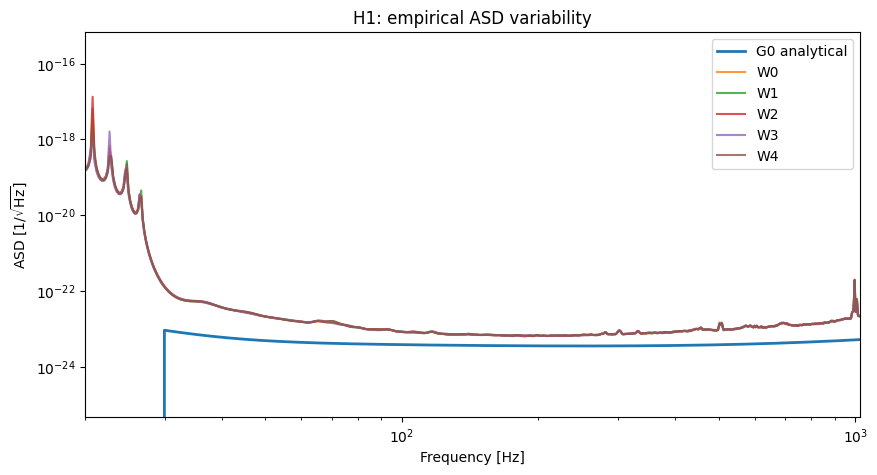

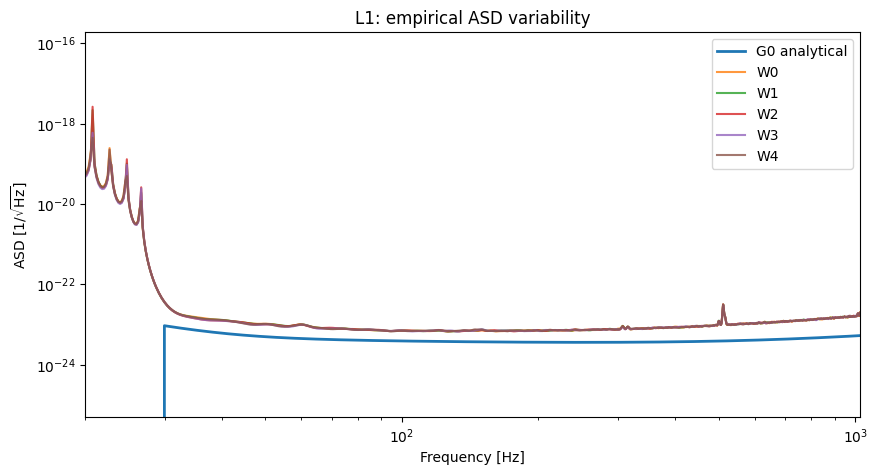

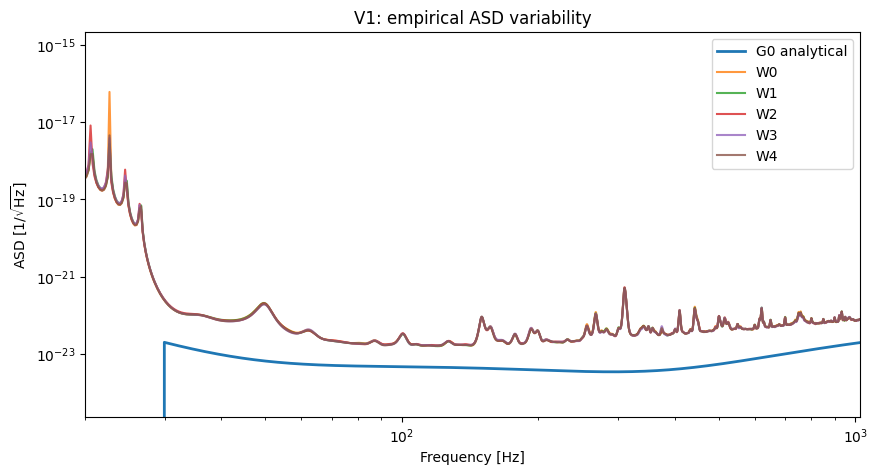

In [111]:
for ifo in DETECTORS:

    plt.figure(
        figsize=(10, 5)
    )

    p0 = analytical_psds_processing[
        ifo
    ]

    f0 = (
        p0.sample_frequencies
        .numpy()
    )

    plt.loglog(
        f0,
        np.sqrt(
            p0.numpy()
        ),
        label="G0 analytical",
        linewidth=2,
    )

    for window_id in PSD_WINDOW_IDS_D:

        p = (
            empirical_psds_processing_D[
                window_id
            ][ifo]
        )

        f = (
            p.sample_frequencies
            .numpy()
        )

        plt.loglog(
            f,
            np.sqrt(
                p.numpy()
            ),
            label=window_id,
            alpha=0.8,
        )

    plt.xlim(20, 1024)

    plt.xlabel(
        "Frequency [Hz]"
    )

    plt.ylabel(
        r"ASD [$1/\sqrt{\mathrm{Hz}}$]"
    )

    plt.title(
        f"{ifo}: empirical ASD variability"
    )

    plt.legend()

    plt.show()

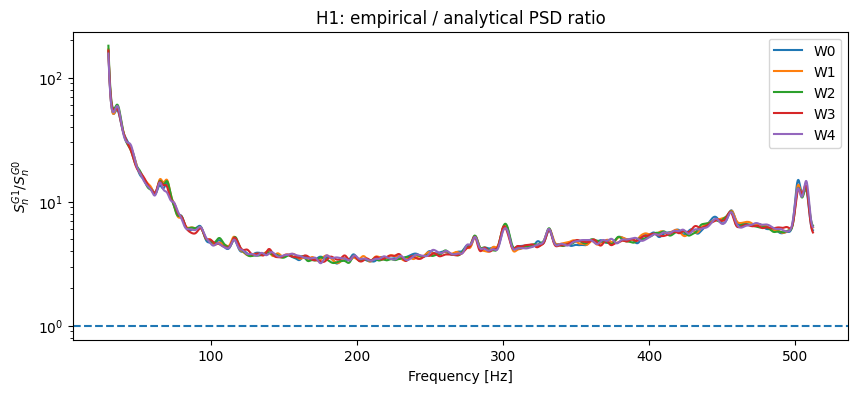

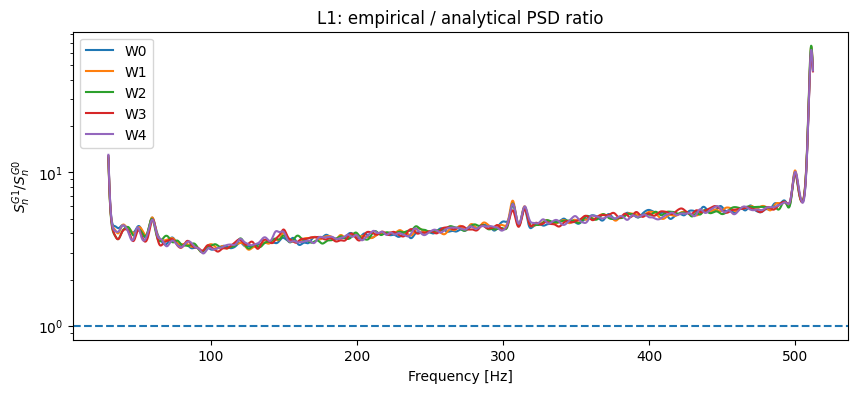

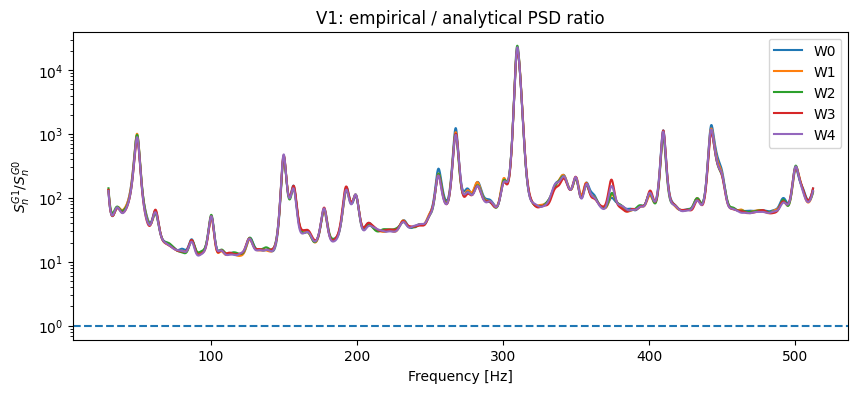

In [112]:
# Ratio Sn,G1/Sb,G0

for ifo in DETECTORS:

    plt.figure(
        figsize=(10, 4)
    )

    p0 = analytical_psds_processing[
        ifo
    ]

    f0 = (
        p0.sample_frequencies
        .numpy()
    )

    a0 = p0.numpy()

    for window_id in PSD_WINDOW_IDS_D:

        p1 = (
            empirical_psds_processing_D[
                window_id
            ][ifo]
        )

        a1 = p1.numpy()

        valid = (
            (f0 >= 30.0)
            & (f0 <= 512.0)
            & (a0 > 0)
            & (a1 > 0)
            & np.isfinite(a0)
            & np.isfinite(a1)
        )

        ratio = (
            a1[valid]
            / a0[valid]
        )

        plt.semilogy(
            f0[valid],
            ratio,
            label=window_id,
        )

    plt.axhline(
        1.0,
        linestyle="--",
    )

    plt.xlabel(
        "Frequency [Hz]"
    )

    plt.ylabel(
        r"$S_n^{G1}/S_n^{G0}$"
    )

    plt.title(
        f"{ifo}: empirical / analytical PSD ratio"
    )

    plt.legend()

    plt.show()

In [113]:
#Bands table

rows = []

for window_id in PSD_WINDOW_IDS_D:

    for ifo in DETECTORS:

        p0 = (
            analytical_psds_processing[
                ifo
            ]
        )

        p1 = (
            empirical_psds_processing_D[
                window_id
            ][ifo]
        )

        f = (
            p0.sample_frequencies
            .numpy()
        )

        a0 = p0.numpy()
        a1 = p1.numpy()

        for fmin, fmax in BANDS:

            mask = (
                (f >= fmin)
                & (f < fmax)
                & (a0 > 0)
                & (a1 > 0)
                & np.isfinite(a0)
                & np.isfinite(a1)
            )

            ratio = (
                a1[mask]
                / a0[mask]
            )

            rows.append({
                "window_id":
                    window_id,
                "ifo":
                    ifo,
                "fmin":
                    fmin,
                "fmax":
                    fmax,
                "median_psd_ratio":
                    np.median(ratio),
                "q10_psd_ratio":
                    np.quantile(
                        ratio,
                        0.10,
                    ),
                "q90_psd_ratio":
                    np.quantile(
                        ratio,
                        0.90,
                    ),
            })

df_D_band_ratios = pd.DataFrame(
    rows
)

df_D_band_ratios

,window_id,ifo,fmin,fmax,median_psd_ratio,q10_psd_ratio,q90_psd_ratio
0,W0,H1,30,60,28.020298,13.398754,54.811551
1,W0,H1,60,120,5.998227,4.388632,12.915483
2,W0,H1,120,256,3.579163,3.373044,3.875045
3,W0,H1,256,512,5.195123,4.223935,6.962971
4,W0,L1,30,60,4.362630,3.963332,4.908100
5,W0,L1,60,120,3.301249,3.150270,3.747862
6,W0,L1,120,256,3.765685,3.395795,4.025709
7,W0,L1,256,512,5.249780,4.338566,6.147098
8,W0,V1,30,60,69.775157,47.673827,518.466350
9,W0,V1,60,120,16.023735,13.346637,43.620719


In [114]:
display(
    df_D_band_ratios.pivot_table(
        index=[
            "window_id",
            "ifo",
        ],
        columns=[
            "fmin",
            "fmax",
        ],
        values="median_psd_ratio",
    )
)

fmin                 30         60         120        256
fmax                 60         120        256        512
window_id ifo                                            
W0        H1   28.020298   5.998227   3.579163   5.195123
          L1    4.362630   3.301249   3.765685   5.249780
          V1   69.775157  16.023735  34.253389  98.587104
W1        H1   27.521962   6.152795   3.601736   5.278306
          L1    4.292667   3.385100   3.794795   5.241630
          V1   72.015765  15.302935  34.685389  95.630939
W2        H1   26.693557   6.124844   3.545258   5.177869
          L1    4.120368   3.364369   3.728446   5.270536
          V1   72.388049  15.731775  34.564983  96.354051
W3        H1   26.710791   5.703961   3.585494   5.159473
          L1    3.983131   3.335455   3.772445   5.293063
          V1   67.847189  15.376472  35.479381  95.688185
W4        H1   29.232816   5.996122   3.606465   5.083683
          L1    4.179409   3.357180   3.806199   5.166938
          V1   69.284994  15.356040  33.876331  94.545572

Variability among windows

In [115]:
df_D_variability = (
    df_D_band_ratios
    .groupby(
        [
            "ifo",
            "fmin",
            "fmax",
        ]
    )
    .agg(
        median_ratio_across_windows=(
            "median_psd_ratio",
            "median",
        ),
        min_ratio_across_windows=(
            "median_psd_ratio",
            "min",
        ),
        max_ratio_across_windows=(
            "median_psd_ratio",
            "max",
        ),
        std_ratio_across_windows=(
            "median_psd_ratio",
            "std",
        ),
    )
    .reset_index()
)

df_D_variability[
    "max_over_min"
] = (
    df_D_variability[
        "max_ratio_across_windows"
    ]
    /
    df_D_variability[
        "min_ratio_across_windows"
    ]
)

df_D_variability

,ifo,fmin,fmax,median_ratio_across_windows,min_ratio_across_windows,max_ratio_across_windows,std_ratio_across_windows,max_over_min
0,H1,30,60,27.521962,26.693557,29.232816,1.055311,1.095126
1,H1,60,120,5.998227,5.703961,6.152795,0.177816,1.078688
2,H1,120,256,3.585494,3.545258,3.606465,0.024213,1.017265
3,H1,256,512,5.177869,5.083683,5.278306,0.069981,1.038284
4,L1,30,60,4.179409,3.983131,4.362630,0.148382,1.095277
5,L1,60,120,3.357180,3.301249,3.385100,0.031896,1.025400
6,L1,120,256,3.772445,3.728446,3.806199,0.030061,1.020854
7,L1,256,512,5.249780,5.166938,5.293063,0.047666,1.024410
8,V1,30,60,69.775157,67.847189,72.388049,1.911717,1.066928
9,V1,60,120,15.376472,15.302935,16.023735,0.310607,1.047102


## Fixed-source optimal SNR variability

The same physical projected GW signal is now evaluated using each empirical PSD window.

The waveform, luminosity distance, sky location, detector geometry and placement remain fixed.

Therefore any variation in

$$
\rho_{\rm net,opt}
$$

is caused exclusively by temporal variation of the estimated detector PSD.

In [116]:
rows = []

for window_id in PSD_WINDOW_IDS_D:

    det_snr, net_snr = (
        compute_network_optimal_snr(
            signal_segments=(
                network_P1.signal_segments
            ),
            psds=(
                empirical_psds_4s_D[
                    window_id
                ]
            ),
            config=config,
        )
    )

    row = {
        "window_id":
            window_id,
        "network_rho_opt":
            net_snr,
    }

    for ifo in DETECTORS:
        row[
            f"{ifo}_rho_opt"
        ] = det_snr[ifo]

    rows.append(row)

df_D_snr = pd.DataFrame(rows)

df_D_snr

,window_id,network_rho_opt,H1_rho_opt,L1_rho_opt,V1_rho_opt
0,W0,19.718221,8.457588,17.551840,3.034859
1,W1,19.688427,8.463079,17.507942,3.079354
2,W2,19.757730,8.478800,17.585438,3.038123
3,W3,19.925557,8.484173,17.766090,3.068006
4,W4,19.743380,8.480262,17.557840,3.099748


In [117]:
df_D_snr["network_ratio_vs_G0"] = (
    df_D_snr[
        "network_rho_opt"
    ]
    / net_snr_G0_P1
)

df_D_snr

,window_id,network_rho_opt,H1_rho_opt,L1_rho_opt,V1_rho_opt,network_ratio_vs_G0
0,W0,19.718221,8.457588,17.551840,3.034859,0.441257
1,W1,19.688427,8.463079,17.507942,3.079354,0.440591
2,W2,19.757730,8.478800,17.585438,3.038123,0.442141
3,W3,19.925557,8.484173,17.766090,3.068006,0.445897
4,W4,19.743380,8.480262,17.557840,3.099748,0.441820


In [118]:
rho_values_D = (
    df_D_snr[
        "network_rho_opt"
    ].to_numpy()
)

print(
    "Mean empirical network rho:",
    rho_values_D.mean(),
)

print(
    "Std empirical network rho:",
    rho_values_D.std(
        ddof=1
    ),
)

print(
    "Min empirical network rho:",
    rho_values_D.min(),
)

print(
    "Max empirical network rho:",
    rho_values_D.max(),
)

print(
    "Max/min ratio:",
    rho_values_D.max()
    / rho_values_D.min(),
)

Mean empirical network rho: 19.766662784922012
Std empirical network rho: 0.09265075777164818
Min empirical network rho: 19.688426869499658
Max empirical network rho: 19.9255567393508
Max/min ratio: 1.0120441247755803


$$
CV = \frac{\sigma_{\rho}}{\overline{\rho}}
$$

In [119]:
print(
    "Coefficient of variation:",
    rho_values_D.std(
        ddof=1
    )
    / rho_values_D.mean(),
)

Coefficient of variation: 0.004687223067432611


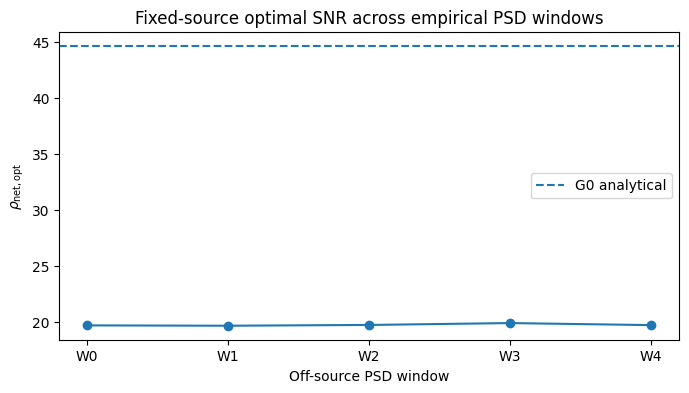

In [121]:
# SNR plot per window

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    PSD_WINDOW_IDS_D,
    df_D_snr[
        "network_rho_opt"
    ],
    marker="o",
)

plt.axhline(
    net_snr_G0_P1,
    linestyle="--",
    label="G0 analytical",
)

plt.xlabel(
    "Off-source PSD window"
)

plt.ylabel(
    r"$\rho_{\rm net,opt}$"
)

plt.title(
    "Fixed-source optimal SNR across empirical PSD windows"
)

plt.legend()

plt.show()

In [122]:
TARGET_RHO_D = 15.0

DISTANCE_REFERENCE_D = (
    network_P1.params.distance
)

df_D_snr[
    "distance_for_rho15_mpc"
] = (
    DISTANCE_REFERENCE_D
    * df_D_snr[
        "network_rho_opt"
    ]
    / TARGET_RHO_D
)

df_D_snr[
    [
        "window_id",
        "network_rho_opt",
        "distance_for_rho15_mpc",
    ]
]

,window_id,network_rho_opt,distance_for_rho15_mpc
0,W0,19.718221,657.274037
1,W1,19.688427,656.280896
2,W2,19.757730,658.590986
3,W3,19.925557,664.185225
4,W4,19.743380,658.112654


In [124]:
# Variability relative to the PSD used in C (the first window)

REFERENCE_WINDOW_D = "W0"

In [125]:
rho_ref_D = float(
    df_D_snr.loc[
        df_D_snr[
            "window_id"
        ] == REFERENCE_WINDOW_D,
        "network_rho_opt",
    ].iloc[0]
)

df_D_snr[
    "rho_ratio_vs_C_reference"
] = (
    df_D_snr[
        "network_rho_opt"
    ]
    / rho_ref_D
)

df_D_snr

,window_id,network_rho_opt,H1_rho_opt,L1_rho_opt,V1_rho_opt,network_ratio_vs_G0,distance_for_rho15_mpc,rho_ratio_vs_C_reference
0,W0,19.718221,8.457588,17.551840,3.034859,0.441257,657.274037,1.000000
1,W1,19.688427,8.463079,17.507942,3.079354,0.440591,656.280896,0.998489
2,W2,19.757730,8.478800,17.585438,3.038123,0.442141,658.590986,1.002004
3,W3,19.925557,8.484173,17.766090,3.068006,0.445897,664.185225,1.010515
4,W4,19.743380,8.480262,17.557840,3.099748,0.441820,658.112654,1.001276


Variable to measure the distance between PDSs:

$$
D_{PSD}​(w_a​,w_b​)=\sqrt{⟨[\log_{10}​ S_{w_a}​​(f)−\log_{10}​ S_{w_b}​​(f)]^2⟩}
​$$

In [126]:
def log_psd_distance(
    psd_a,
    psd_b,
    fmin=30.0,
    fmax=512.0,
):
    f = (
        psd_a
        .sample_frequencies
        .numpy()
    )

    a = psd_a.numpy()
    b = psd_b.numpy()

    mask = (
        (f >= fmin)
        & (f <= fmax)
        & (a > 0)
        & (b > 0)
        & np.isfinite(a)
        & np.isfinite(b)
    )

    diff = (
        np.log10(a[mask])
        - np.log10(b[mask])
    )

    return float(
        np.sqrt(
            np.mean(
                diff**2
            )
        )
    )

In [127]:
#wrt to W0

rows = []

for ifo in DETECTORS:

    ref = (
        empirical_psds_processing_D[
            REFERENCE_WINDOW_D
        ][ifo]
    )

    for window_id in PSD_WINDOW_IDS_D:

        p = (
            empirical_psds_processing_D[
                window_id
            ][ifo]
        )

        rows.append({
            "ifo":
                ifo,
            "window_id":
                window_id,
            "log_psd_distance_vs_W0":
                log_psd_distance(
                    ref,
                    p,
                ),
        })

df_D_psd_distance = pd.DataFrame(
    rows
)

df_D_psd_distance

,ifo,window_id,log_psd_distance_vs_W0
0,H1,W0,0.000000
1,H1,W1,0.016555
2,H1,W2,0.018786
3,H1,W3,0.021045
4,H1,W4,0.020000
5,L1,W0,0.000000
6,L1,W1,0.015280
7,L1,W2,0.021326
8,L1,W3,0.021136
9,L1,W4,0.020404


# M11.4 — Final conclusions

M11.4 investigated one specific component of the synthetic-to-real domain gap: the replacement of the fixed analytical detector PSDs used in M10 by empirical PSDs estimated from real off-source detector strain.

The study deliberately kept the stochastic noise Gaussian in order to isolate the effect of the PSD from genuine real-noise non-Gaussianity and non-stationarity.

## M11.4-A — Analytical versus empirical PSD

The empirical detector PSDs differ strongly from the analytical M10 design curves.

The disagreement is both detector-dependent and frequency-dependent.

For the GW170814 epoch, the empirical PSD is systematically higher than the analytical reference across the relevant frequency range, with the largest discrepancy observed for Virgo.

Therefore the transition

$$
G0 =
\text{Gaussian noise + analytical PSD}
$$

to

$$
G1 =
\text{Gaussian noise + empirical PSD}
$$

is not a small perturbation of the detector-noise model.

The empirical PSD also contains spectral structure that is absent from the smooth analytical design curves.

## M11.4-B — Effect on the same physical GW

The same physical $30+30\,M_\odot$ BBH source at fixed distance produces very different optimal SNR under the two detector-noise models.

For the controlled source,

$$
\rho_{\rm net,opt}^{G0}
\simeq 44.69,
$$

whereas

$$
\rho_{\rm net,opt}^{G1}
\simeq 19.72.
$$

Thus

$$
\frac{
\rho_{\rm net,opt}^{G1}
}{
\rho_{\rm net,opt}^{G0}
}
\simeq 0.44.
$$

The effect is strongly detector dependent and particularly large for Virgo.

Frequency-resolved SNR analysis shows that this reduction cannot be described by a single global scaling factor.

Instead,

$$
S_n^{G1}(f)
\neq
C\,S_n^{G0}(f),
$$

so the relative contribution of different frequency regions to

$$
\rho^2
$$

changes between domains.

This is relevant for parameter estimation because different frequency regions carry different information about the binary parameters.

## Fixed-optimal-SNR control

To remove the total detectability change as a confounding variable, a second controlled experiment imposed

$$
\rho_{\rm net,opt}^{G0}
=
\rho_{\rm net,opt}^{G1}
=
15.
$$

This required different luminosity distances,

$$
d_{G0}
\simeq 1489.6\ {\rm Mpc},
$$

and

$$
d_{G1}
\simeq 657.3\ {\rm Mpc}.
$$

This construction does not represent two observations of the same astrophysical event.

Instead, it is a controlled experiment designed to isolate the effect of PSD shape at fixed total optimal SNR.

## M11.4-C — Paired Gaussian G0/G1 comparison

A paired Gaussian-noise generator was explicitly constructed in the frequency domain.

For each detector and realization, the same underlying Gaussian draw

$$
w_I(f)
$$

was colored independently with either

$$
S_{n,I}^{G0}(f)
$$

or

$$
S_{n,I}^{G1}(f).
$$

The pairing was numerically validated, the generated strain amplitude was consistent with PyCBC Gaussian-noise generation, and the matched-filter fluctuation recovered

$$
E[\Delta\rho]\simeq0,
$$

$$
\mathrm{Std}(\Delta\rho)\simeq1.
$$

Therefore the noisy G0/G1 comparison can be interpreted as a controlled PSD-domain experiment rather than a comparison contaminated by independent noise realizations.

After domain-matched whitening and the frozen M10 per-sample/per-detector z-score normalization, the final processed inputs remain highly similar between G0 and G1 for H1 and L1, while Virgo shows a larger residual shift.

Thus the preprocessing pipeline removes a large fraction of the very large raw PSD mismatch.

Nevertheless, the PSD change is not completely eliminated.

A measurable latent-space displacement remains, indicating that the frozen M10 CNN can distinguish the two Gaussian PSD domains internally.

At prediction level, however, the average G0-to-G1 shifts are relatively small and no strong systematic degradation is observed at fixed optimal SNR.

Individual paired realizations can still exhibit non-negligible parameter shifts.

Therefore the main M11.4-C result is:

> PSD shape alone produces a measurable input and latent-domain shift, but under the tested fixed-SNR controlled source the frozen M10 predictor remains comparatively robust on average.

The empirical PSD does not by itself explain the full synthetic-to-real performance gap.

## M11.4-D — Local empirical PSD variability

Five validated off-source PSD windows around GW170814 were compared.

Across these nearby windows, the empirical PSD is remarkably stable relative to the much larger G0-to-G1 difference.

The maximum-to-minimum ratio of the median PSD discrepancy across windows remains approximately within

$$
1.02-1.10
$$

depending on detector and frequency band.

For the same fixed physical source,

$$
\bar\rho_{\rm net,opt}
\simeq19.77,
$$

with

$$
\sigma_{\rho}
\simeq0.093,
$$

and

$$
\frac{\sigma_\rho}{\bar\rho}
\simeq0.0047.
$$

The full observed range is only approximately

$$
19.69
\le
\rho_{\rm net,opt}
\le
19.93.
$$

Likewise, the distance required to enforce

$$
\rho_{\rm net,opt}=15
$$

varies only from approximately

$$
656.3\ {\rm Mpc}
$$

to

$$
664.2\ {\rm Mpc}.
$$

Therefore the PSD window used in M11.4-C is reasonably representative of the nearby off-source conditions tested here.

This does not imply that detector PSDs are globally stationary.

Larger temporal separations, different observing days and different observing runs may show substantially greater variability.

That broader temporal study is left for a later population-level noise-model analysis.

## Overall interpretation

M11.4 separates two effects that should not be conflated:

$$
\text{PSD mismatch}
$$

and

$$
\text{true real-noise structure}.
$$

The empirical PSD differs strongly from the analytical M10 detector model and changes both total detectability and frequency weighting.

However, once the Gaussian noise is generated and whitened consistently with its own PSD, much of this discrepancy is removed by the preprocessing pipeline.

The remaining shift is visible in the normalized inputs and latent representation, but does not produce a large systematic prediction degradation in the controlled fixed-SNR experiment.

Therefore the evidence suggests that

$$
\boxed{
\text{PSD mismatch is a real component of the domain gap, but is unlikely to be the dominant one by itself.}
}
$$

The next major source of mismatch to investigate is the use of actual real off-source detector strain, which introduces effects that cannot be represented by a second-order PSD model alone, including non-Gaussianity, non-stationarity, transient artifacts and other detector-specific structure.

## Decision

M11.4 is considered closed.

The empirical PSD will be retained as an important part of the realistic-noise pipeline, but no further expansion of the single-epoch PSD study is required before moving to real off-source noise.

A broader study of PSD variability across larger temporal baselines and observing runs may be revisited later when constructing the final training-domain distribution.